# DATA 602 Team 5: Airline Passenger Satisfaction Exploratory Data Analysis (Model Training and Fine-Tuning)
**Group Members:**
- Brett Allen
- Eeshani Gundi
- Sruthi Kapudasi
- Bharath Prabhakaran
- Nandhu Unnikrishnan

**Due Date:** 11/07/2024

## Setup

In [77]:
!python -m pip install -q scikit-learn sklearn_evaluation scipy pandas numpy pyarrow seaborn umap-learn xgboost

### Imports

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Any
import warnings
import os
from scipy.stats import randint
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve
)
from sklearn_evaluation import plot
from sklearn.preprocessing import (
    StandardScaler, 
    MinMaxScaler, 
    FunctionTransformer, 
    QuantileTransformer, 
    OneHotEncoder, 
    KBinsDiscretizer
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import umap

### Configurations

In [5]:
sns.set_style('darkgrid')

In [6]:
warnings.filterwarnings('ignore')

In [7]:
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning'

## Load Master Data (Clean)
Use master dataset that was cleaned as part of EDA deliverable.

In [8]:
# X = pd.read_parquet('../datasets/clean/master_data.parquet')
X = pd.read_csv('../datasets/clean/master_data.csv')
X.shape

(103594, 23)

In [9]:
X.head()

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103594 entries, 0 to 103593
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   GENDER                             103594 non-null  object 
 1   CUSTOMER_TYPE                      103594 non-null  object 
 2   AGE                                103594 non-null  int64  
 3   TYPE_OF_TRAVEL                     103594 non-null  object 
 4   CLASS                              103594 non-null  object 
 5   FLIGHT_DISTANCE                    103594 non-null  int64  
 6   INFLIGHT_WIFI_SERVICE              103594 non-null  int64  
 7   DEPARTURE_ARRIVAL_TIME_CONVENIENT  103594 non-null  int64  
 8   EASE_OF_ONLINE_BOOKING             103594 non-null  int64  
 9   GATE_LOCATION                      103594 non-null  int64  
 10  FOOD_AND_DRINK                     103594 non-null  int64  
 11  ONLINE_BOARDING                    1035

In [11]:
# Verify there are no null values
X.isnull().sum()

GENDER                               0
CUSTOMER_TYPE                        0
AGE                                  0
TYPE_OF_TRAVEL                       0
CLASS                                0
FLIGHT_DISTANCE                      0
INFLIGHT_WIFI_SERVICE                0
DEPARTURE_ARRIVAL_TIME_CONVENIENT    0
EASE_OF_ONLINE_BOOKING               0
GATE_LOCATION                        0
FOOD_AND_DRINK                       0
ONLINE_BOARDING                      0
SEAT_COMFORT                         0
INFLIGHT_ENTERTAINMENT               0
ON-BOARD_SERVICE                     0
LEG_ROOM_SERVICE                     0
BAGGAGE_HANDLING                     0
CHECKIN_SERVICE                      0
INFLIGHT_SERVICE                     0
CLEANLINESS                          0
DEPARTURE_DELAY_IN_MINUTES           0
ARRIVAL_DELAY_IN_MINUTES             0
SATISFACTION                         0
dtype: int64

### Converting specified columns to suitable data types

In [12]:
categorical_columns = [
    'GENDER', 'CUSTOMER_TYPE', 'TYPE_OF_TRAVEL', 'CLASS', 'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING', 'GATE_LOCATION', 
    'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT', 'INFLIGHT_ENTERTAINMENT', 
    'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE', 'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 
    'INFLIGHT_SERVICE', 'CLEANLINESS'
]

# Numerical columns for discretization
numerical_columns = [
    'AGE', 'FLIGHT_DISTANCE', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES'
]

# Convert types accordingly
X[categorical_columns] = X[categorical_columns].astype('category')
X[numerical_columns] = X[numerical_columns].astype('int64')

# Check the data types
print(X.dtypes)

GENDER                               category
CUSTOMER_TYPE                        category
AGE                                     int64
TYPE_OF_TRAVEL                       category
CLASS                                category
FLIGHT_DISTANCE                         int64
INFLIGHT_WIFI_SERVICE                category
DEPARTURE_ARRIVAL_TIME_CONVENIENT    category
EASE_OF_ONLINE_BOOKING               category
GATE_LOCATION                        category
FOOD_AND_DRINK                       category
ONLINE_BOARDING                      category
SEAT_COMFORT                         category
INFLIGHT_ENTERTAINMENT               category
ON-BOARD_SERVICE                     category
LEG_ROOM_SERVICE                     category
BAGGAGE_HANDLING                     category
CHECKIN_SERVICE                      category
INFLIGHT_SERVICE                     category
CLEANLINESS                          category
DEPARTURE_DELAY_IN_MINUTES              int64
ARRIVAL_DELAY_IN_MINUTES          

## Prepare the Data for Training

In [18]:
# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('discretizer', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform'))
        ]), numerical_columns),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_columns)
    ]
)

In [19]:
# Define target
target_column = 'SATISFACTION'

### Analyze Class Imbalance

In [20]:
label_counts = X[target_column].value_counts()
pd.DataFrame({'counts': label_counts, 'ratio': label_counts / len(X)})

,counts,ratio
SATISFACTION,,
neutral or dissatisfied,58697,0.566606
satisfied,44897,0.433394


There is a slight class imbalance favoring `neutral or dissatisfied` as the majority and `satisfied` as the minority. We can relieve this imbalance by upsampling the minority class.

### Apply Upsampling to Minority Class

In [21]:
def apply_resampling(df: pd.DataFrame, col: str, do_upsample=True) -> pd.DataFrame:
    value_counts = df[col].value_counts()
    sample_size = value_counts.max() if do_upsample else value_counts.min()
    print('sample_size = {} ({})'.format(sample_size, 'Upsampling' if do_upsample else 'Downsampling'))
    
    counts_df = pd.DataFrame({col: value_counts.index, 'count': value_counts.values})
    resampled_data = pd.DataFrame()
    
    for label in counts_df[col]:
        data = df[df[col] == label]
        n = len(data)
        
        # Determine if resampling is needed
        if (do_upsample and n < sample_size) or (not do_upsample and n > sample_size):
            # Resample the data
            resampled_label = resample(data, replace=True, n_samples=sample_size, random_state=42)
            resampled_data = pd.concat([resampled_data, resampled_label])
        else:
            resampled_data = pd.concat([resampled_data, data])
            
    return resampled_data

In [22]:
X_upSampled = apply_resampling(
    X,
    col=target_column, 
    do_upsample=True
)

sample_size = 58697 (Upsampling)


In [23]:
# Verify change to label counts
upsampled_label_counts = X_upSampled[target_column].value_counts()
pd.DataFrame({'counts': upsampled_label_counts, 'ratio': upsampled_label_counts / len(X)})

,counts,ratio
SATISFACTION,,
neutral or dissatisfied,58697,0.566606
satisfied,58697,0.566606


In [24]:
# Apply the change
# NOTE: Skipping as this does not improve model accuracy
# X = X_upSampled.copy(deep=True)

### Create Label Encoding

In [25]:
# Categorical encoding
for idx, value in enumerate(X[target_column].value_counts().to_dict()):
    print(idx, value)

0 neutral or dissatisfied
1 satisfied


In [26]:
# Categorical encode target for analysis
label_to_id = {}
id_to_label = {}
for idx, value in enumerate(X[target_column].value_counts().to_dict()):
    label_to_id[value] = idx
    id_to_label[idx] = value

### Encode Categorical String Features

In [27]:
for col in categorical_columns:
    print(f'Column = "{col}", Dtype = "{X[col].dtype}", Subtype = {type(X[col].iloc[0])}')

Column = "GENDER", Dtype = "category", Subtype = <class 'str'>
Column = "CUSTOMER_TYPE", Dtype = "category", Subtype = <class 'str'>
Column = "TYPE_OF_TRAVEL", Dtype = "category", Subtype = <class 'str'>
Column = "CLASS", Dtype = "category", Subtype = <class 'str'>
Column = "INFLIGHT_WIFI_SERVICE", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "DEPARTURE_ARRIVAL_TIME_CONVENIENT", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "EASE_OF_ONLINE_BOOKING", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "GATE_LOCATION", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "FOOD_AND_DRINK", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "ONLINE_BOARDING", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "SEAT_COMFORT", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "INFLIGHT_ENTERTAINMENT", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "ON-BOARD_SERVICE", Dtype = "category", Subtype = <cl

In [28]:
category_str_cols = [ col for col in categorical_columns if isinstance(X[col].iloc[0], str) and col != target_column ]
category_str_cols

['GENDER', 'CUSTOMER_TYPE', 'TYPE_OF_TRAVEL', 'CLASS']

In [29]:
category_str_cols_map = {}
for col in category_str_cols:
    category_str_cols_map[col] = { 'label_to_id': {}, 'id_to_label': {} }
    for idx, value in enumerate(X[col].value_counts().to_dict()):
        category_str_cols_map[col]['label_to_id'][value] = idx
        category_str_cols_map[col]['id_to_label'][idx] = value

    X[col] = X[col].apply(lambda x: category_str_cols_map[col]['label_to_id'][x])
category_str_cols_map

{'GENDER': {'label_to_id': {'Female': 0, 'Male': 1},
  'id_to_label': {0: 'Female', 1: 'Male'}},
 'CUSTOMER_TYPE': {'label_to_id': {'Loyal Customer': 0,
   'disloyal Customer': 1},
  'id_to_label': {0: 'Loyal Customer', 1: 'disloyal Customer'}},
 'TYPE_OF_TRAVEL': {'label_to_id': {'Business travel': 0,
   'Personal Travel': 1},
  'id_to_label': {0: 'Business travel', 1: 'Personal Travel'}},
 'CLASS': {'label_to_id': {'Business': 0, 'Eco': 1, 'Eco Plus': 2},
  'id_to_label': {0: 'Business', 1: 'Eco', 2: 'Eco Plus'}}}

In [30]:
# Convert the category columns to int now that they all represent integers
# NOTE: This is mainly applicable to logistic regression; need to make sure this does not hinder performance of other models
for col in categorical_columns:
    if col != target_column:
        X[col] = X[col].astype(int)

In [31]:
X.head(1).T

,0
GENDER,1
CUSTOMER_TYPE,0
AGE,13
TYPE_OF_TRAVEL,1
CLASS,2
FLIGHT_DISTANCE,460
INFLIGHT_WIFI_SERVICE,3
DEPARTURE_ARRIVAL_TIME_CONVENIENT,4
EASE_OF_ONLINE_BOOKING,3
GATE_LOCATION,1


In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103594 entries, 0 to 103593
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   GENDER                             103594 non-null  int64   
 1   CUSTOMER_TYPE                      103594 non-null  int64   
 2   AGE                                103594 non-null  int64   
 3   TYPE_OF_TRAVEL                     103594 non-null  int64   
 4   CLASS                              103594 non-null  int64   
 5   FLIGHT_DISTANCE                    103594 non-null  int64   
 6   INFLIGHT_WIFI_SERVICE              103594 non-null  int64   
 7   DEPARTURE_ARRIVAL_TIME_CONVENIENT  103594 non-null  int64   
 8   EASE_OF_ONLINE_BOOKING             103594 non-null  int64   
 9   GATE_LOCATION                      103594 non-null  int64   
 10  FOOD_AND_DRINK                     103594 non-null  int64   
 11  ONLINE_BOARDING           

### Create Train/Test Split

#### Separate Features and Labels

In [32]:
y = X[target_column]
X = X.drop(target_column, axis=1)

In [33]:
X.shape, y.shape

((103594, 22), (103594,))

#### Encode Labels for Training

In [34]:
# Apply encoding map to labels
y = y.apply(lambda x: label_to_id.get(x, x))

In [35]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: SATISFACTION, dtype: int64

#### Apply 80/20 Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((82875, 22), (20719, 22), (82875,), (20719,))

In [38]:
# Analyze split ratio (goal is an 80/20 train/test split)
X_len = len(X_train) + len(X_test)
round(len(X_train) / X_len, 2), round(len(X_test) / X_len, 2)

(0.8, 0.2)

We can see that the test/train split has a perfect 80/20 split and we can proceed.

### Apply Transformations to Features

In [39]:
def generate_histplots(data: pd.DataFrame, ncols: int=4, bins=20, title: str='Distribution per Feature', figsize: tuple=(20, 15), **kwargs):
    """
    Generate histogram plots for dataset to analyze distribution of the data.

    Args:
        data (pd.DataFrame): Dataset to generate histogram plots for.
        ncols (int, optional): Number of column in the produced figure. Defaults to 4.
        bins (int, optional): Number of bins for each histogram plot. Defaults to 20.
        title (str, optional): Title of the figure. Defaults to 'Histogram Plots'.
        figsize (tuple, optional): Size of the figure. Defaults to (20, 15).
    """
    if data is None or data.empty:
        return
    
    # Dynamically determine number of columns and rows for subplots
    ncols = min(ncols, len(data.columns))
    nrows = (len(data.columns) + ncols - 1) // ncols

    # Create subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    # Flatten 2D axes array to 1D
    if max(nrows, ncols) > 1:
        axes = axes.ravel()
    else:
        axes = np.array([axes])

    for i, col in enumerate(data.columns):
        sns.histplot(data=data[col], ax=axes[i], bins=bins, **kwargs)
        axes[i].set_title(col)
        axes[i].set(xticklabels=[], xticks=[])

    # Remove unused plots
    for i in range(len(data.columns), nrows * ncols):
        fig.delaxes(axes[i])
    
    if title:
        fig.suptitle(title, weight='bold')
        
    plt.tight_layout()
    plt.show()

#### Standard Scaler

In [40]:
standard_scaler = StandardScaler()
X_train_standardScaled = standard_scaler.fit_transform(X_train)
X_train_standardScaled = pd.DataFrame(X_train_standardScaled, columns=X_train.columns)

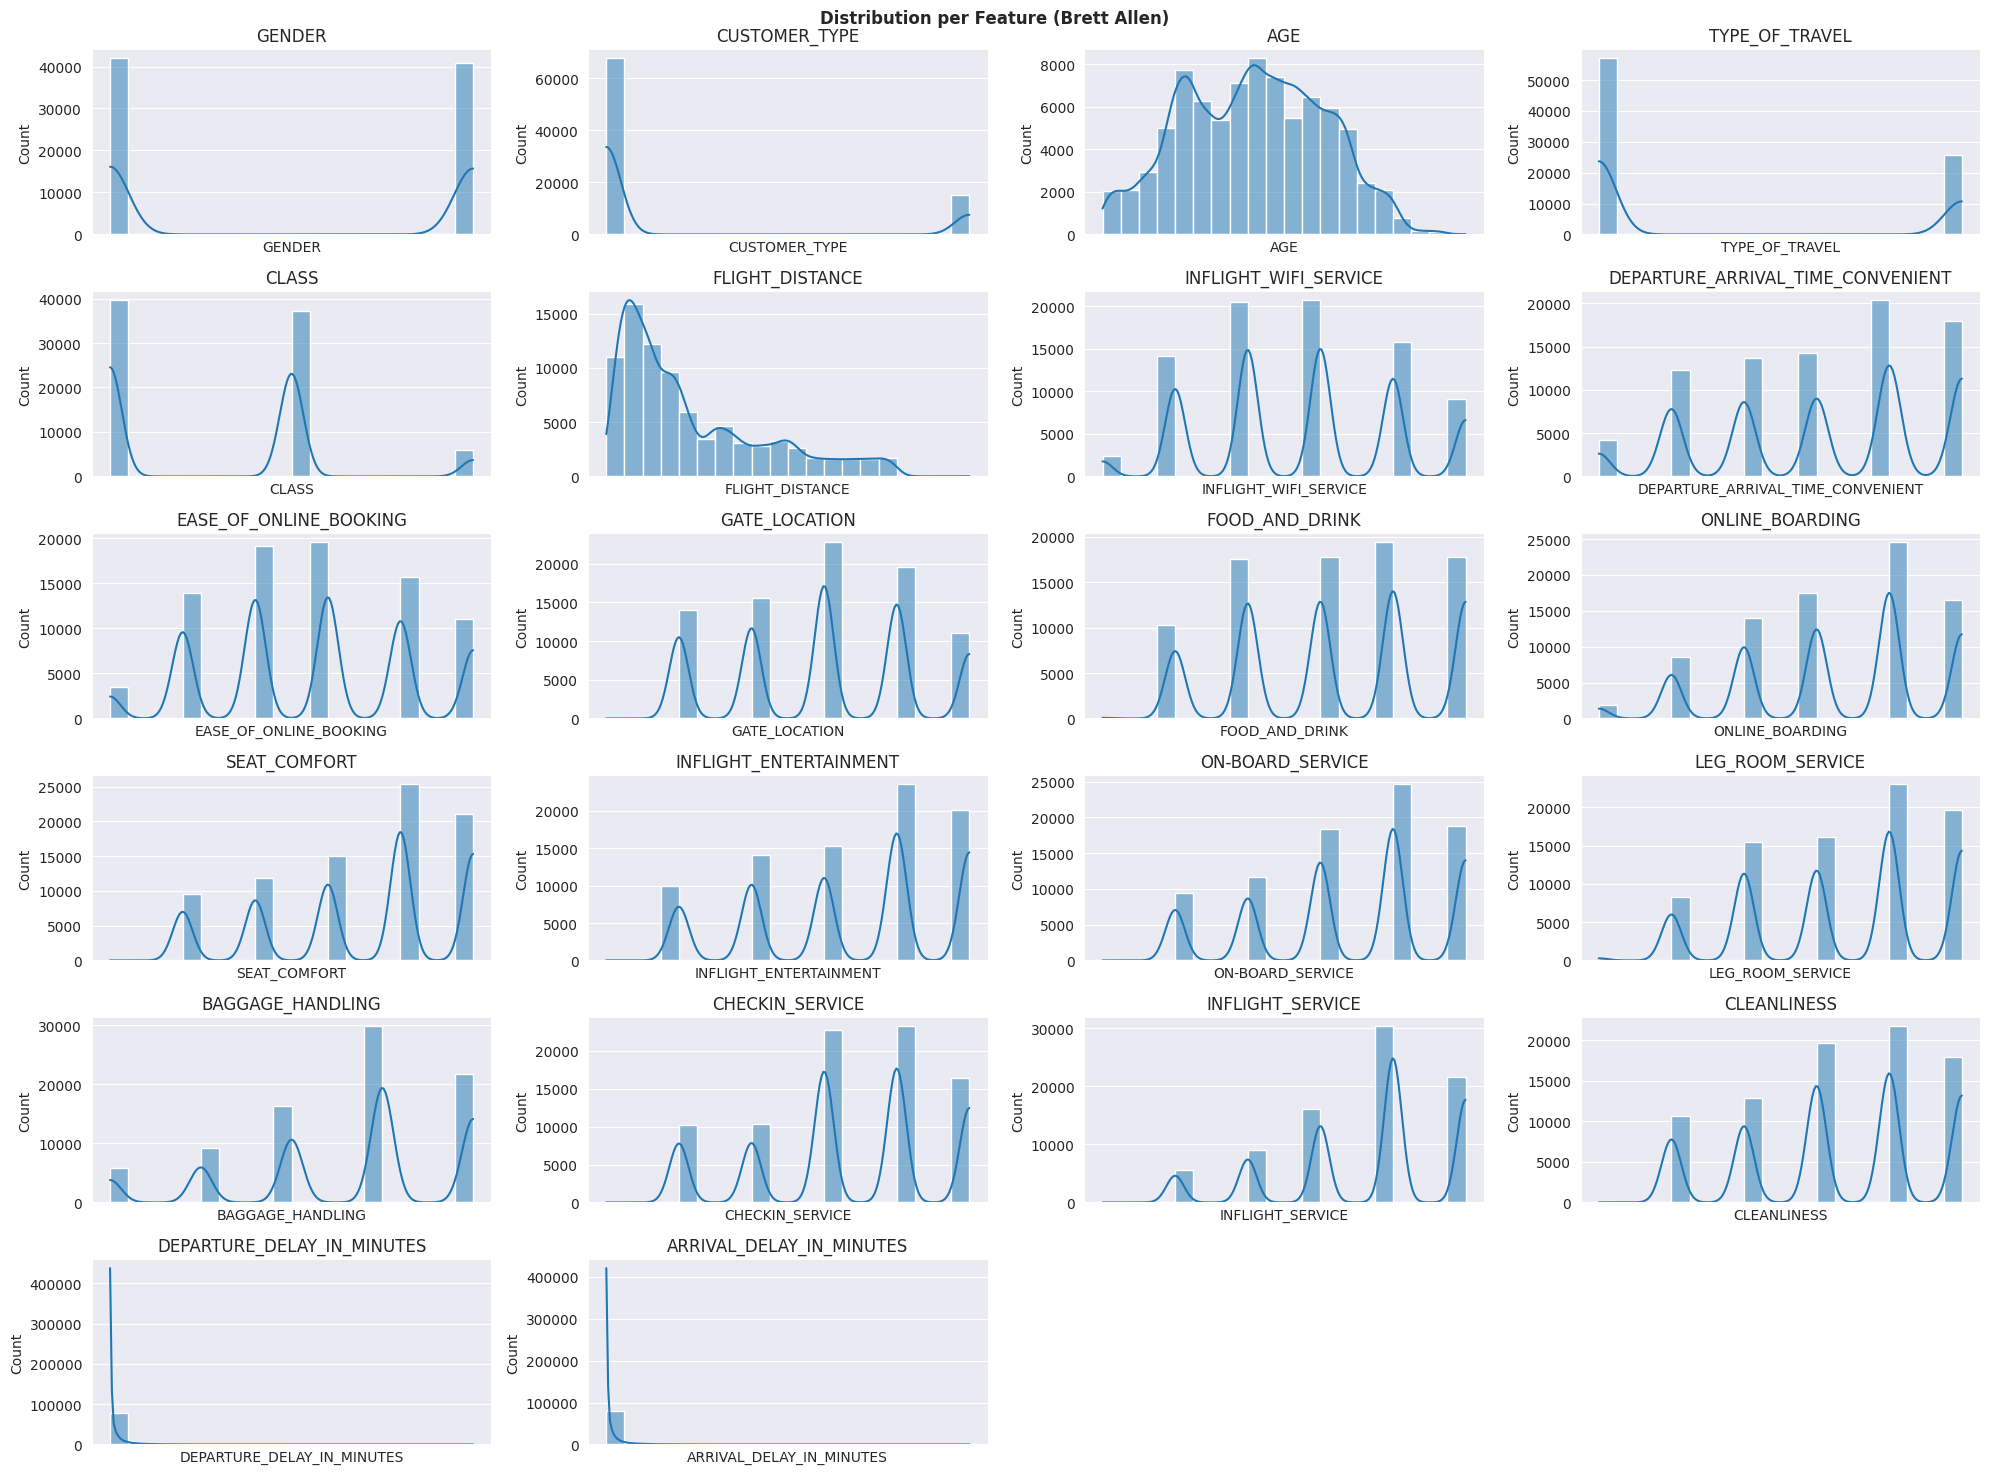

In [41]:
generate_histplots(X_train_standardScaled, kde=True, title='Distribution per Feature (Brett Allen)')

#### Min/Max Scaler

In [42]:
min_max_scaler = MinMaxScaler()
X_train_minMaxScaled = min_max_scaler.fit_transform(X_train)
X_train_minMaxScaled = pd.DataFrame(X_train_minMaxScaled, columns=X_train.columns)

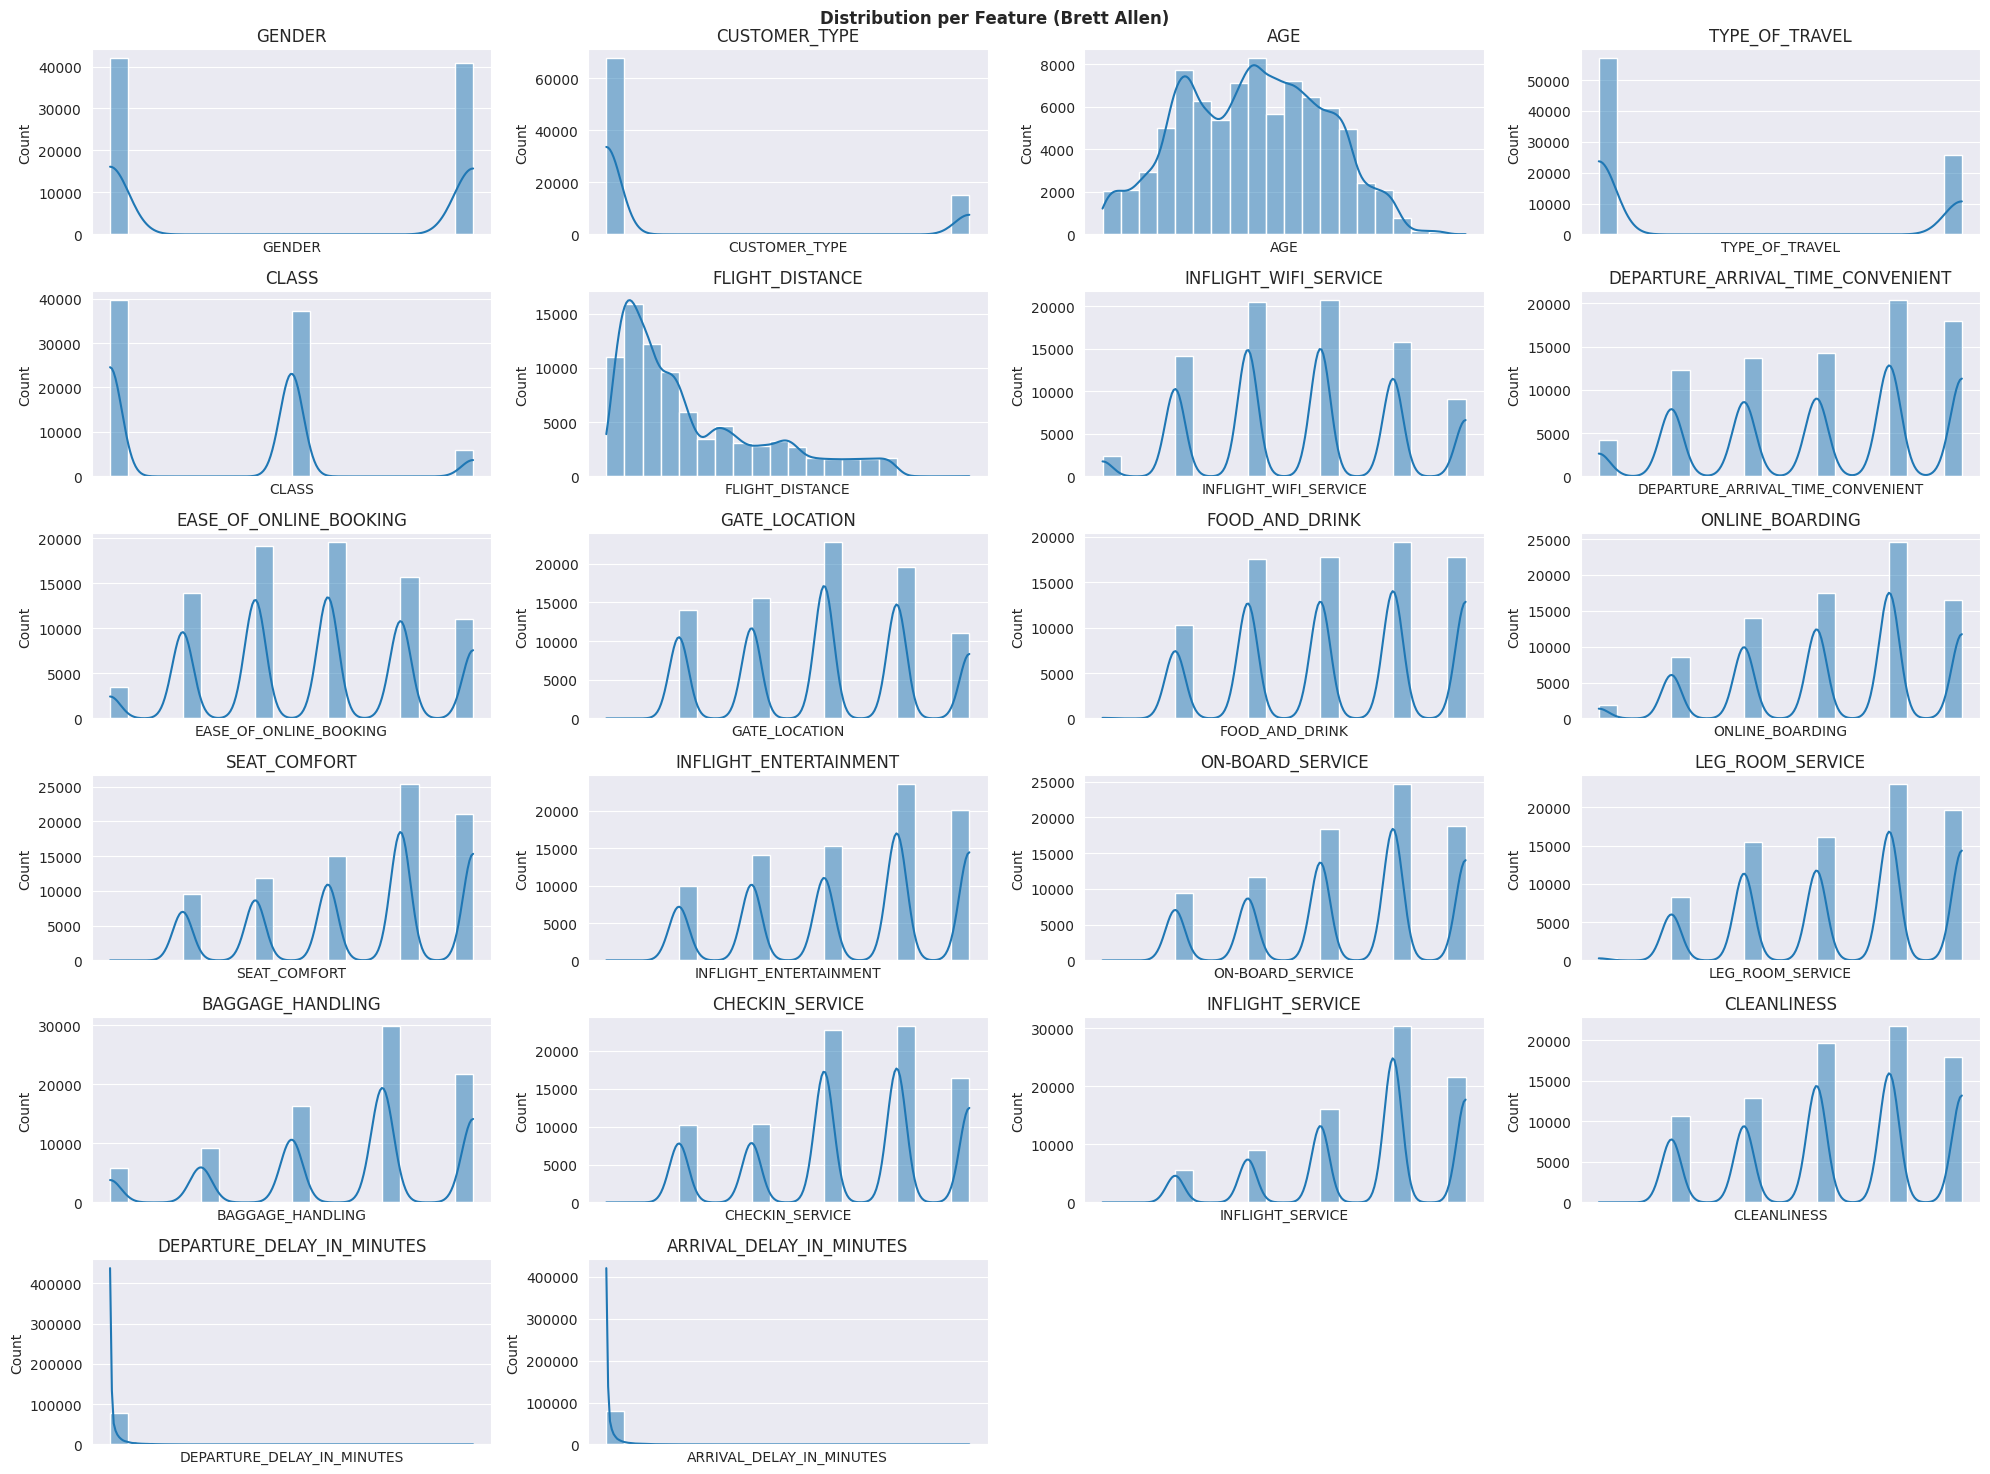

In [43]:
generate_histplots(X_train_minMaxScaled, kde=True, title='Distribution per Feature (Brett Allen)')

#### Quantile Transform

In [44]:
quantile_transform = QuantileTransformer()
X_train_quantileTransformed = quantile_transform.fit_transform(X_train)
X_train_quantileTransformed = pd.DataFrame(X_train_quantileTransformed, columns=X_train.columns)

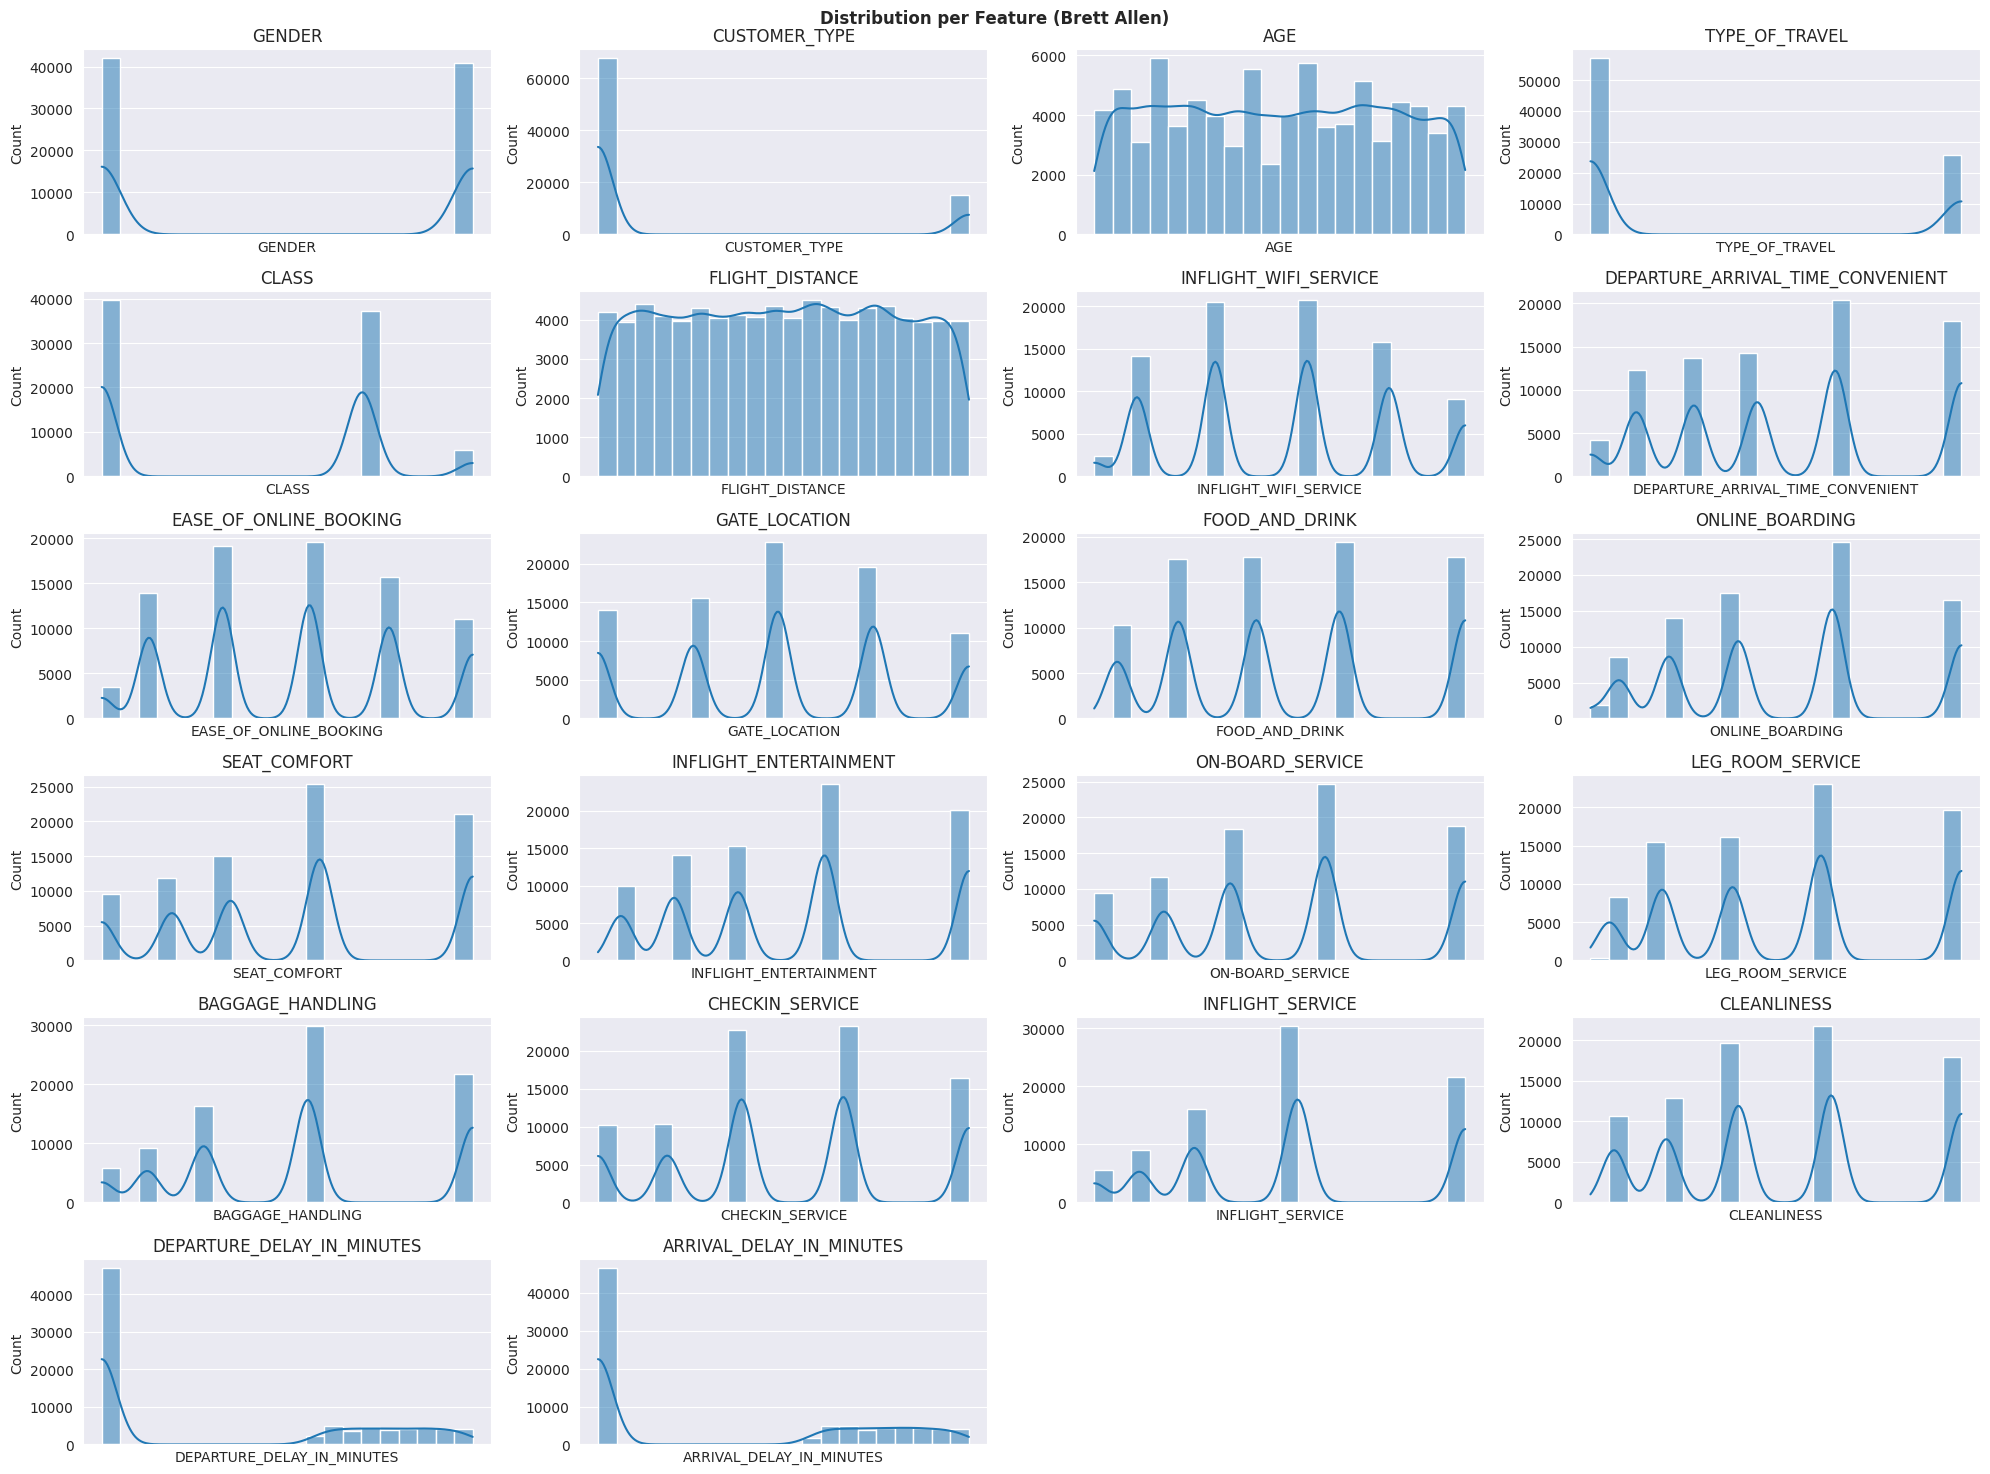

In [45]:
generate_histplots(X_train_quantileTransformed, kde=True, title='Distribution per Feature (Brett Allen)')

#### Log Transform

In [46]:
log_transformer = FunctionTransformer(func=np.log1p)
X_train_logTransformed = log_transformer.fit_transform(X_train)
X_train_logTransformed = pd.DataFrame(X_train_logTransformed, columns=X_train.columns)

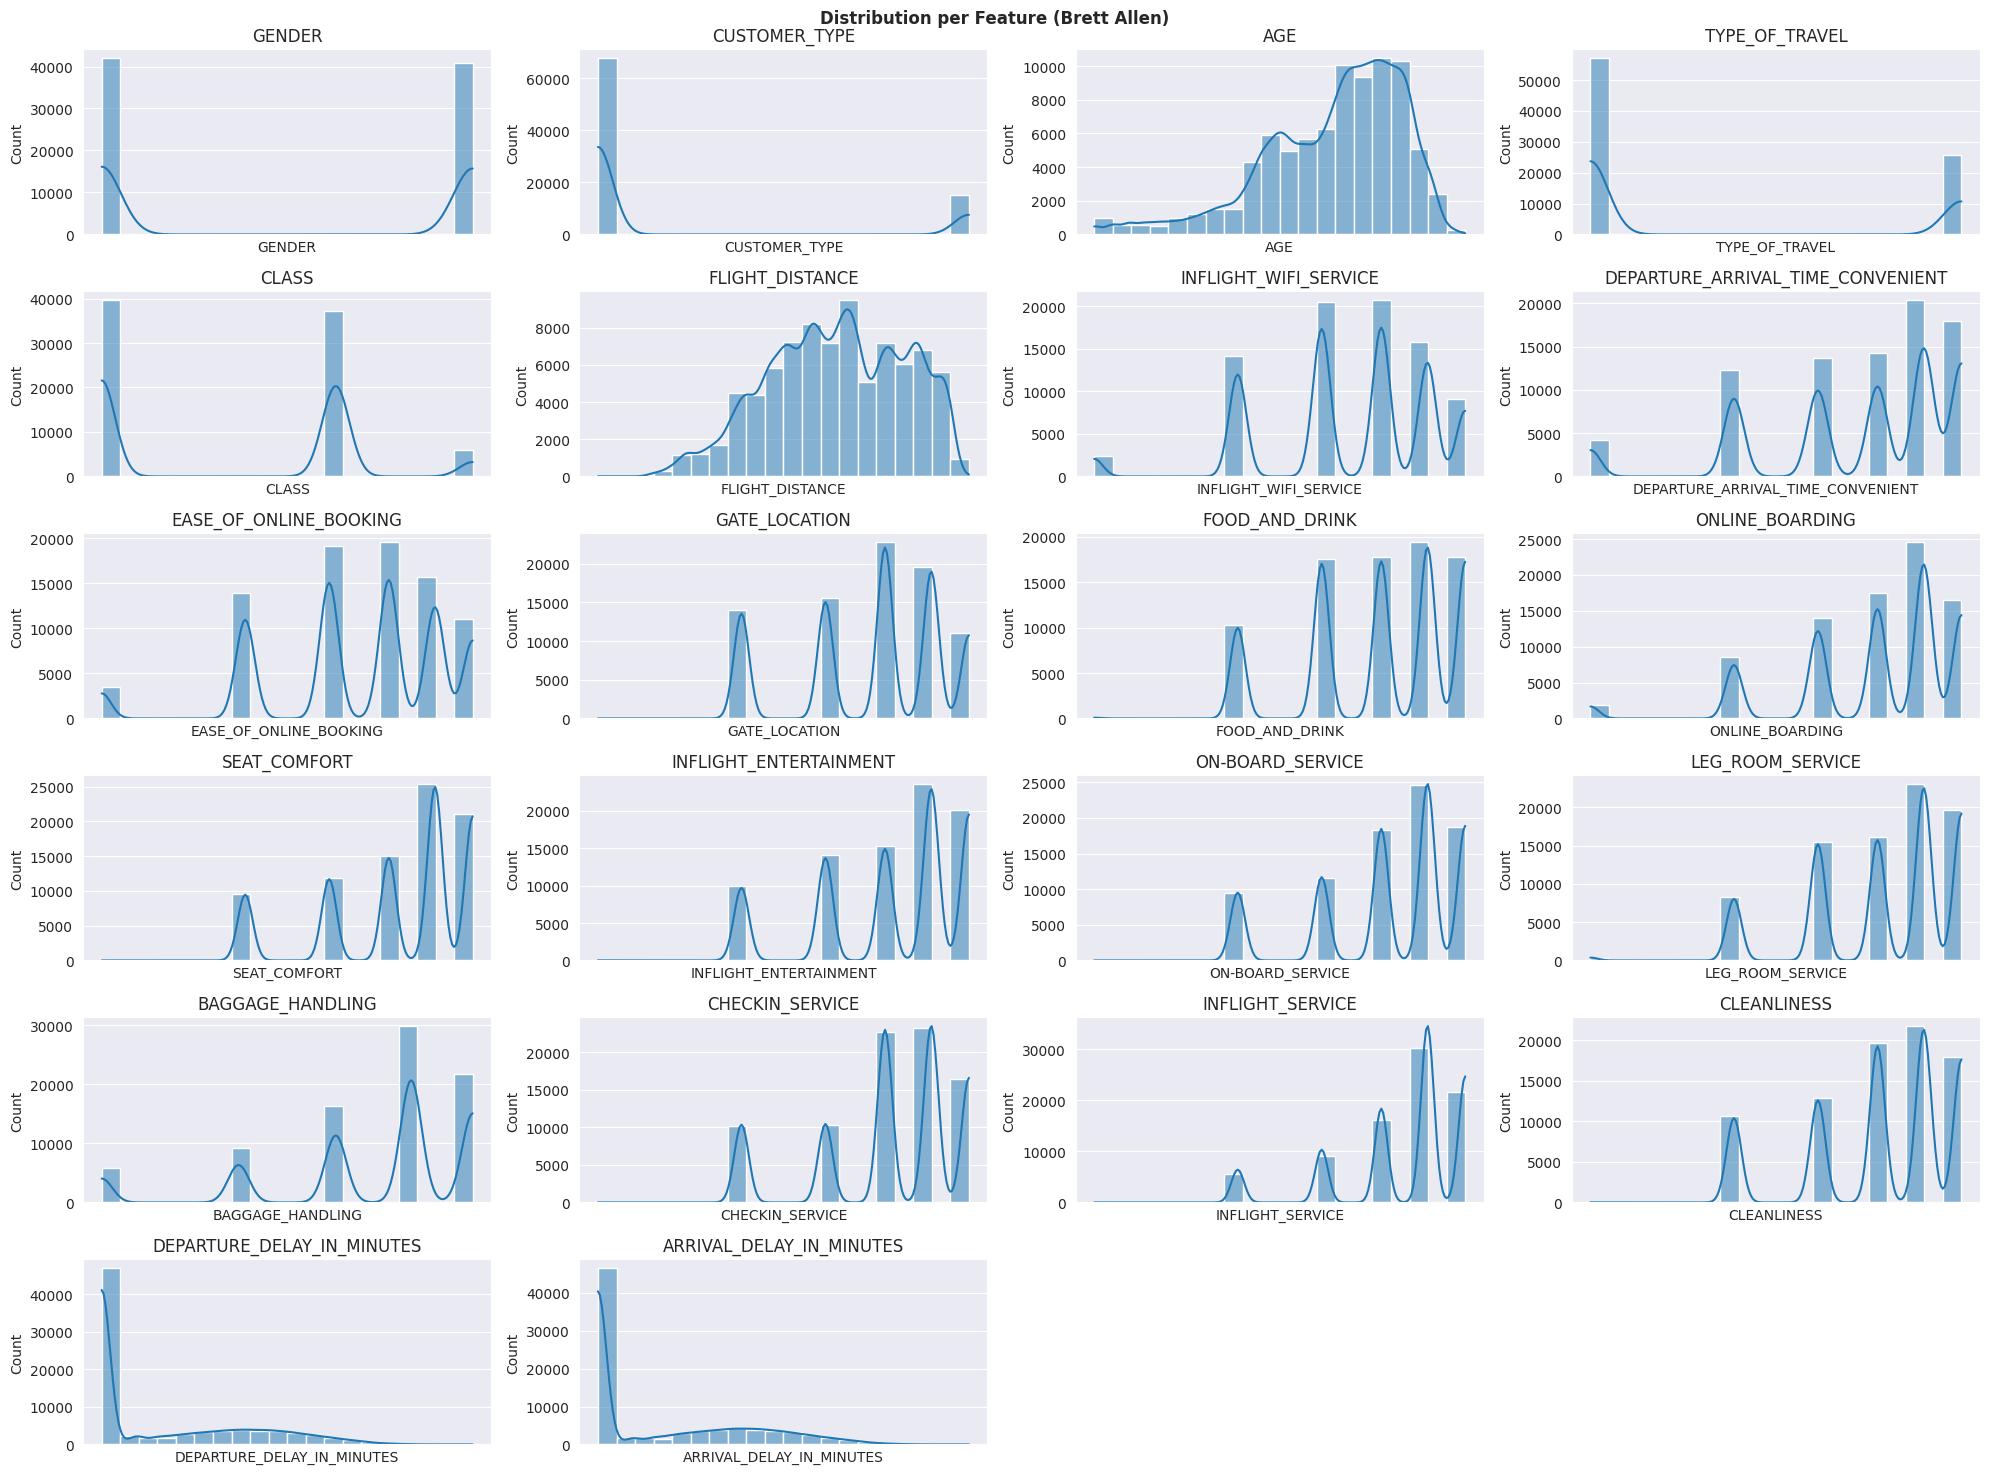

In [47]:
generate_histplots(X_train_logTransformed, kde=True, title='Distribution per Feature (Brett Allen)')

Quantile transform and log transform seem to yield the best results for feature scaling in terms of the resulting distributions of the features. Standard scaler and min/max scaler struggled with arrival and departure delay in minutes features while quantile transform and log transform handled those features better. Thus, will use quantile transform for model training.

## Apply Transformations to Test Data

In [48]:
X_test_standardScaled = standard_scaler.transform(X_test)
X_test_standardScaled = pd.DataFrame(X_test_standardScaled, columns=X_test.columns)

In [49]:
X_test_minMaxScaled = min_max_scaler.transform(X_test)
X_test_minMaxScaled = pd.DataFrame(X_test_minMaxScaled, columns=X_test.columns)

In [50]:
X_test_quantileTransformed = quantile_transform.transform(X_test)
X_test_quantileTransformed = pd.DataFrame(X_test_quantileTransformed, columns=X_test.columns)

In [51]:
# Apply log transform to test data
X_test_logTransformed = log_transformer.transform(X_test)
X_test_logTransformed = pd.DataFrame(X_test_logTransformed, columns=X_test.columns)

## Feature Selection
Use Random Forest classifier to identify most important features and select those features.

In [52]:
# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_quantileTransformed, y_train)

# Evaluate the model
accuracy_before = rf.score(X_test_quantileTransformed, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

Accuracy before feature selection: 0.96


In [53]:
importances = rf.feature_importances_
feature_names = X_train_quantileTransformed.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [54]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)

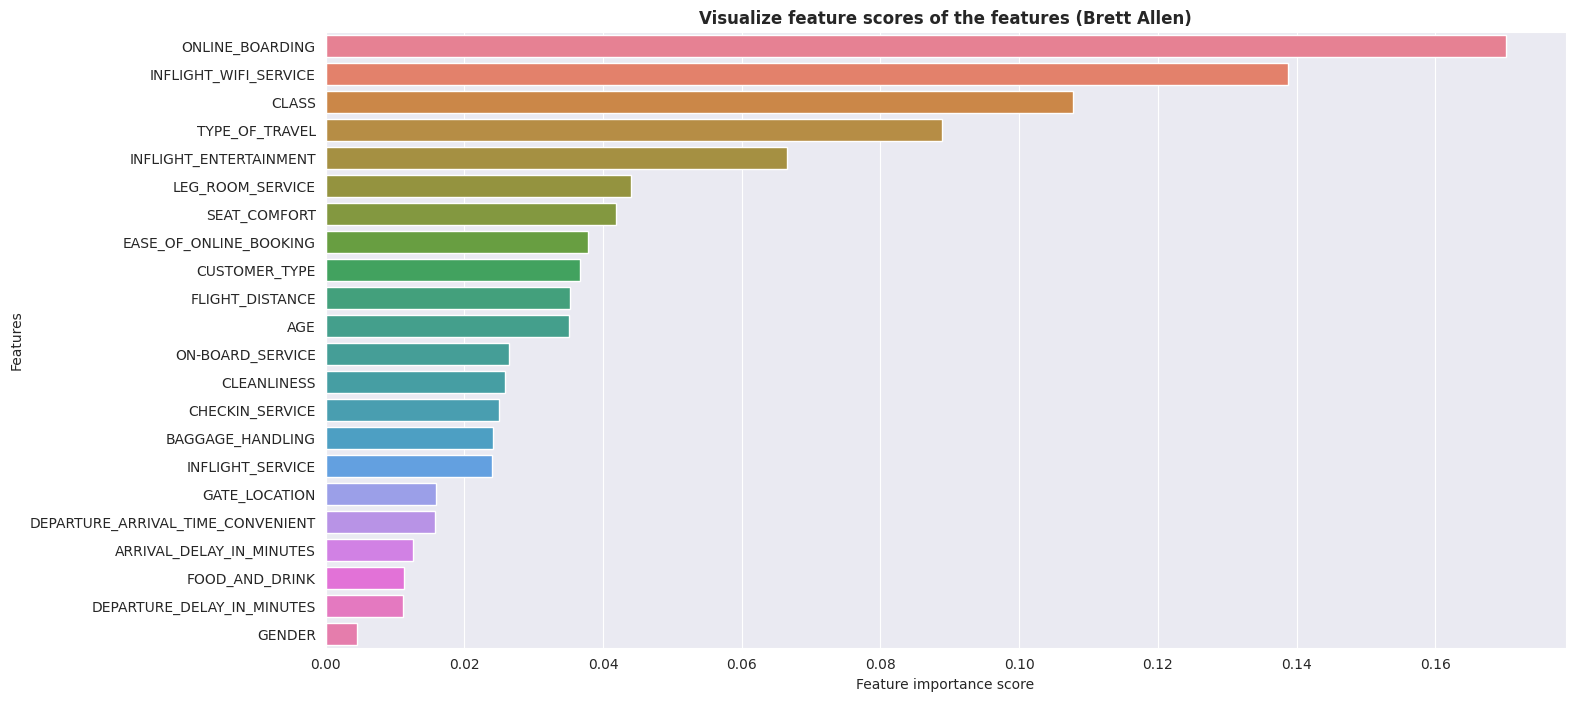

In [55]:
f, ax = plt.subplots(figsize=(16, 8))
ax = sns.barplot(data=feature_importance_df, x='Importance', y='Feature', hue='Feature', legend=False)
ax.set_title("Visualize feature scores of the features (Brett Allen)", weight='bold')
ax.set_xlabel("Feature importance score")
ax.set_ylabel("Features")
plt.show()

## Model Training, Evaluation, and Fine-Tuning
The models we have selected for training are as follows:
* Logistic Regression
* Gradient Boosting
* XGBoost
* SVC
* Random Forest Classifier
* AdaBoost

### Logistic Regression (Brett Allen)
**NOTE:** Since we are dealing with a binary classification problem, we do not need Softmax regression (which is applicable to multiple classes). Therefore, we will use logistic regression.

In [56]:
logreg_model = LogisticRegression(
    max_iter=1000, 
    C=0.1, 
    penalty="l2",
    random_state=42
)
# logreg_model.fit(X_train_logTransformed, y_train)
logreg_model.fit(X_train_quantileTransformed, y_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=42)

#### Evaluation

In [57]:
# Compute confusion matrix
def plot_cm(cm, model_name, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.gca().grid(False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

In [58]:
# NOTE: Default threshold = 0.5 for binary classification
def plot_precision_recall_curve(y_true, y_scores, model_name, threshold=0.5):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
    plt.plot(thresholds, recalls[:-1], 'g--', label='Recall', linewidth=2)
    plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label='Threshold')

    # Add intersection points, axis label, legend, and title
    idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
    plt.plot(thresholds[idx], precisions[idx], "bo")
    plt.plot(thresholds[idx], recalls[idx], "go")
    plt.xlabel("Threshold")
    plt.legend(loc="lower left")
    plt.title(f"{model_name} Precision Recall Curve")
    plt.show()

In [59]:
def plot_roc_curve(y_true, y_scores, model_name):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc_score(y_true, y_scores):.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f'{model_name} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='best')
    plt.show()

In [60]:
def quick_evaluate(model, test_data, test_labels, model_name, display_labels):
    # Make predictions with the given model
    y_pred = model.predict(test_data)
    y_scores = model.predict_proba(test_data)
    
    # Calculate and print accuraacy on training data
    accuracy = accuracy_score(test_labels, y_pred)
    
    print(f">>> {model_name} accuracy: {accuracy}")
    cm = confusion_matrix(test_labels, y_pred)
    
    # Print classification report for detailed metrics per class
    print("Classification Report:\n", classification_report(test_labels, y_pred))
    
    plot_cm(cm, model_name, display_labels)
    plot_precision_recall_curve(y_test, y_scores[:,-1], model_name)
    plot_roc_curve(y_test, y_scores[:,-1], model_name)

 #### Logistic Regression

>>> Logistic Regression (Brett Allen) accuracy: 0.8821854336599256
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.88      0.88     20719
weighted avg       0.88      0.88      0.88     20719



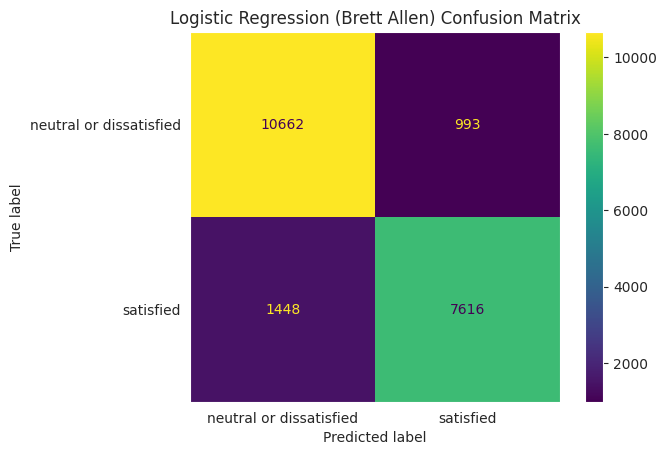

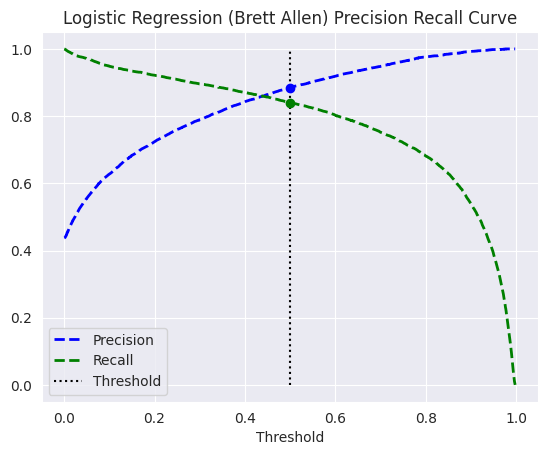

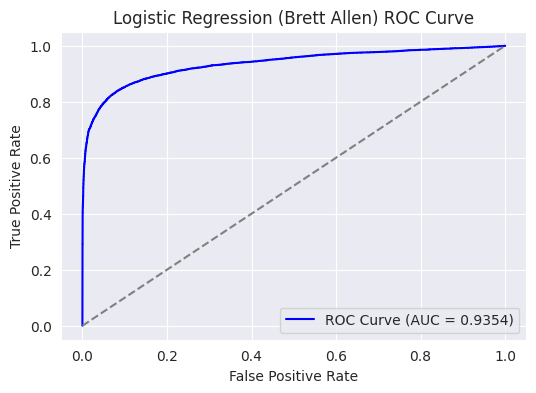

In [61]:
# logreg_model
quick_evaluate(
    model=logreg_model,
    test_data=X_test_quantileTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Logistic Regression (Brett Allen)"
)

#### Fine-Tuning

##### Grid Search with Cross Validation

In [62]:
# Define the parameter grid
# ================= ============================== ======================
# solver            penalty                        multinomial multiclass
# ================= ============================== ======================
# 'lbfgs'           'l2', None                     yes
# 'liblinear'       'l1', 'l2'                     no
# 'newton-cg'       'l2', None                     yes
# 'newton-cholesky' 'l2', None                     no
# 'sag'             'l2', None                     yes
# 'saga'            'elasticnet', 'l1', 'l2', None yes
# ================= ============================== ======================
logreg_param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.1, 1, 5, 50, 1000],
    'max_iter': [50, 100, 1000, 10000],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'l1_ratio': [0.1, 0.25, 0.5, 0.75],
    'random_state': [42],
}

# Initialize Logistic Regression model
logreg_model = LogisticRegression()

# Initialize GridSearchCV
grid_search_logreg = GridSearchCV(
    estimator=logreg_model, 
    param_grid=logreg_param_grid, 
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

# Perform Grid Search on the training data
grid_search_logreg.fit(X_train_quantileTransformed, y_train)    

# Retrieve the best parameters
best_params_logreg = grid_search_logreg.best_params_
print(f"Best parameters for Logistic Regression with Grid Search: {best_params_logreg}")

Best parameters for Logistic Regression with Grid Search: {'C': 0.1, 'l1_ratio': 0.75, 'max_iter': 50, 'penalty': 'elasticnet', 'random_state': 42, 'solver': 'saga'}


>>> Fine-Tuned Logistic Regression (Grid Search CV) (Brett Allen) accuracy: 0.8821371687822771
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.88      0.88     20719
weighted avg       0.88      0.88      0.88     20719



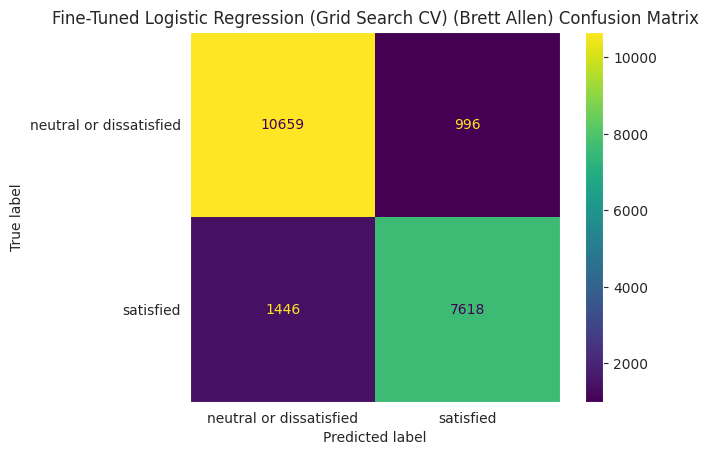

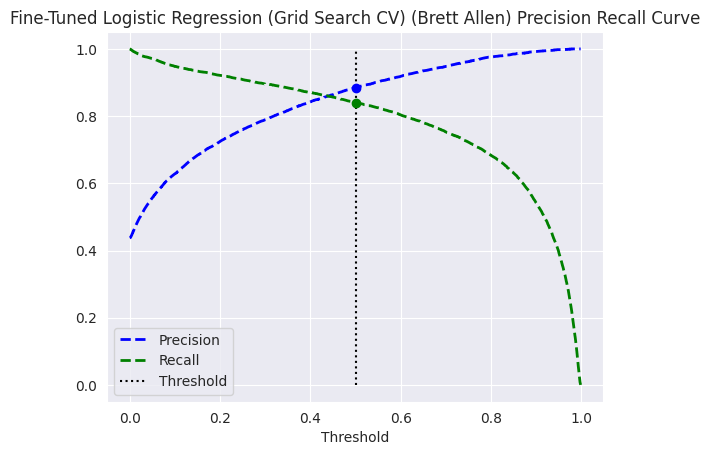

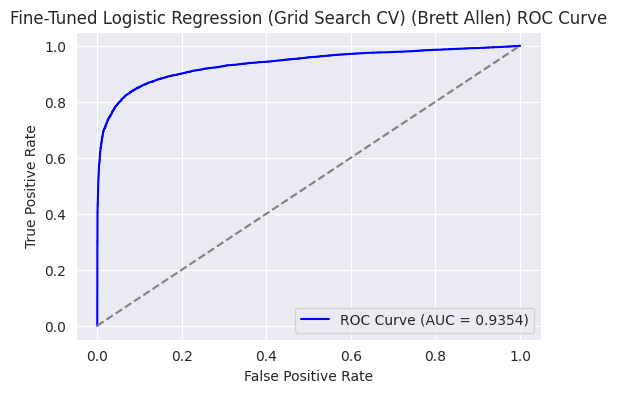

In [63]:
quick_evaluate(
    model=grid_search_logreg.best_estimator_,
    test_data=X_test_quantileTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (Grid Search CV) (Brett Allen)"
)

##### Random Search with Cross Validation

In [64]:
# RandomizedSearchCV
# See page 94 in Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow textbook
logreg_param_rand_search = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': randint(low=1, high=50),
    'max_iter': randint(low=50, high=1000),
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'random_state': [42],
}

rnd_search_logreg = RandomizedSearchCV(
    LogisticRegression(),
    logreg_param_rand_search,
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

# Perform Random Search on the training data
rnd_search_logreg.fit(X_train_quantileTransformed, y_train)

# Retrieve the best parameters
best_params_rnd_search_logreg = rnd_search_logreg.best_params_
print(f"Best parameters for Logistic Regression with Random Search: {best_params_rnd_search_logreg}")

Best parameters for Logistic Regression with Random Search: {'C': 21, 'max_iter': 695, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear'}


>>> Fine-Tuned Logistic Regression (Random Search CV) (Brett Allen) accuracy: 0.8819923741493315
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.88      0.88     20719
weighted avg       0.88      0.88      0.88     20719



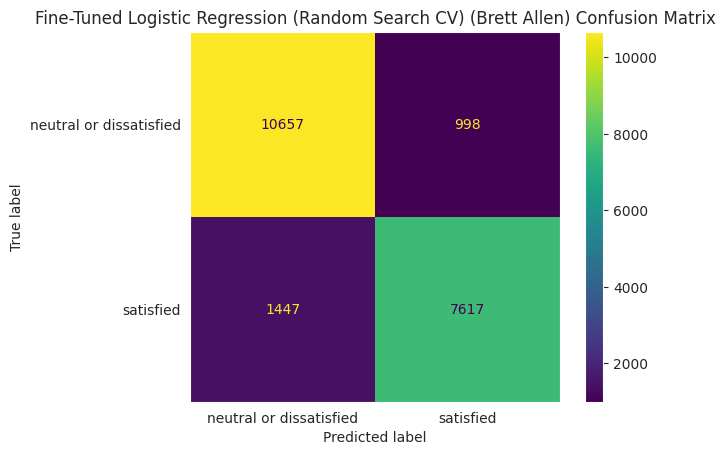

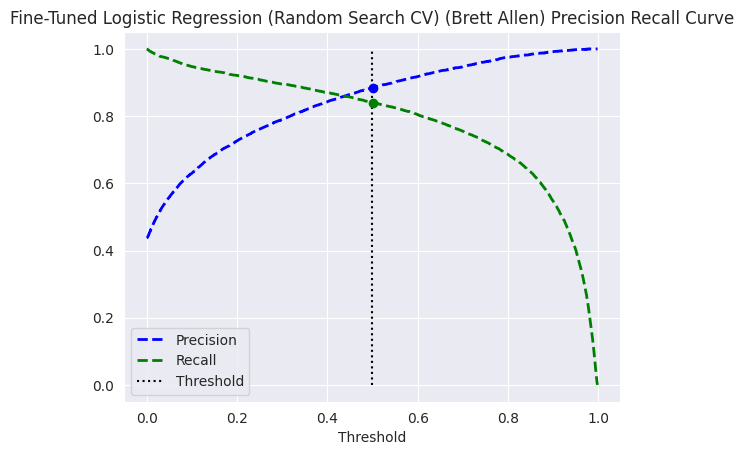

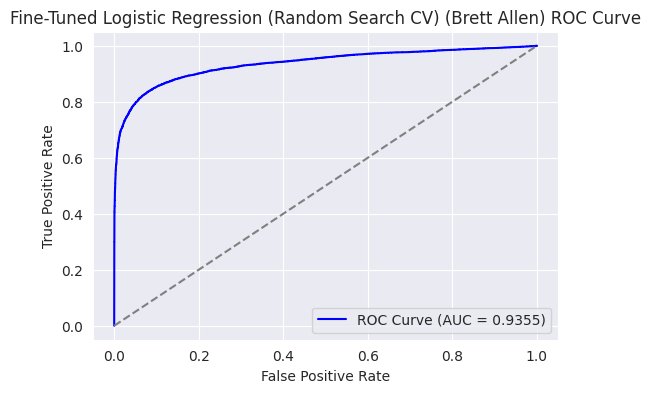

In [65]:
quick_evaluate(
    model=rnd_search_logreg.best_estimator_,
    test_data=X_test_quantileTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (Random Search CV) (Brett Allen)"
)

##### Principal Component Analysis (PCA)

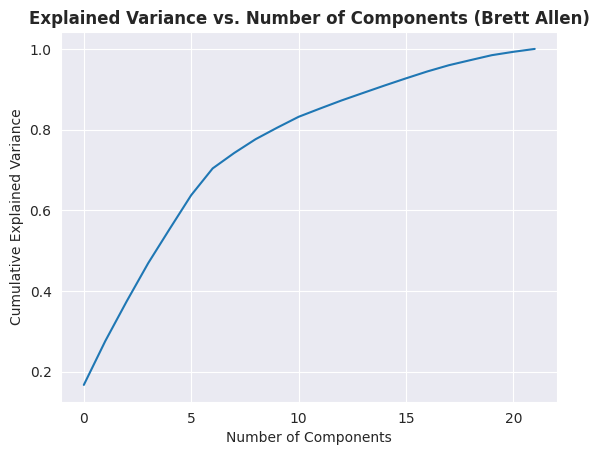

In [66]:
pca = PCA()
pca.fit(X_train_quantileTransformed)

# Calculate the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot the explained variance ratio
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components (Brett Allen)', weight='bold')
plt.show()

Using the **Elbow Method**, we can see that the optimal number of features is between `15` and `20`, which is where the explained variance starts to level off.

In [67]:
# With threshold method
# Choose the number of components that explain 95% of the variance
threshold = 0.95
n_components = np.argmax(np.cumsum(explained_variance_ratio) >= threshold) + 1
print(f'Using {n_components} principal components will explain {round(threshold*100)}% of the variance')

Using 18 principal components will explain 95% of the variance


Given `18` principal components explains `95%` of the variance in the dataset and this finding is in alignment with the observations from the **Elbow Method** since `18` is between `15` and `20`, we will select `18` as the number of components.

**NOTE** Rather than manually applying a threshold, sklearn PCA supports passing in a threshold as the n_components value. For example `PCA(n_components=0.95)`

In [68]:
# Create a new PCA object with the chosen number of components
pca = PCA(n_components=n_components)

# Fit and transform the data
X_pca = pca.fit_transform(X_train_quantileTransformed)

In [69]:
# logreg_pca_pipeline = Pipeline([
#     ('pca', PCA(n_components=n_components)),
#     ('logreg', LogisticRegression(**best_params_logreg)),
# ])

logreg_pca_pipeline = Pipeline([
    ('pca', PCA(n_components=n_components)),
    ('grid_search_logreg', GridSearchCV(
        estimator=LogisticRegression(),
        param_grid=logreg_param_grid, 
        cv=5,
        scoring='accuracy', 
        n_jobs=-1
    ))
])

logreg_pca_pipeline.fit(X_train_quantileTransformed, y_train)

Pipeline(steps=[('pca', PCA(n_components=np.int64(18))),
                ('grid_search_logreg',
                 GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
                              param_grid={'C': [0.1, 1, 5, 50, 1000],
                                          'l1_ratio': [0.1, 0.25, 0.5, 0.75],
                                          'max_iter': [50, 100, 1000, 10000],
                                          'penalty': ['l1', 'l2', 'elasticnet'],
                                          'random_state': [42],
                                          'solver': ['liblinear', 'lbfgs',
                                                     'saga']},
                              scoring='accuracy'))])

In [70]:
# Retrieve the best parameters
best_params_logreg_pca = logreg_pca_pipeline['grid_search_logreg'].best_params_
print(f"Best parameters for Logistic Regression with PCA and GridSearchCV: {best_params_logreg_pca}")

Best parameters for Logistic Regression with PCA and GridSearchCV: {'C': 0.1, 'l1_ratio': 0.1, 'max_iter': 50, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear'}


>>> Fine-Tuned Logistic Regression (PCA and Grid Search CV) (Brett Allen) accuracy: 0.8788551571021768
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.87      0.88     20719
weighted avg       0.88      0.88      0.88     20719



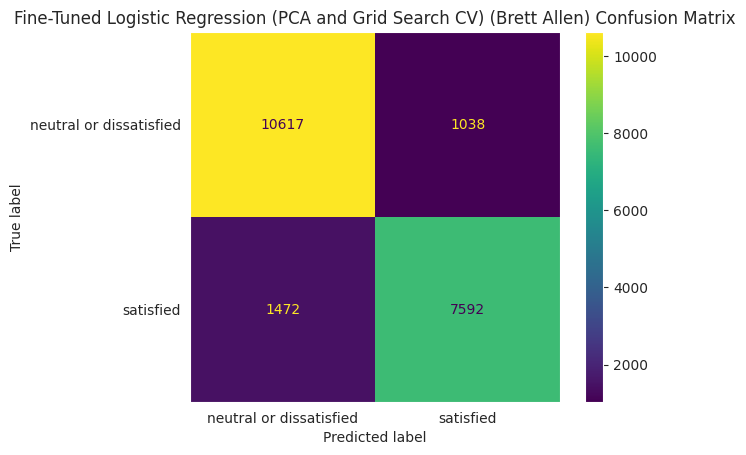

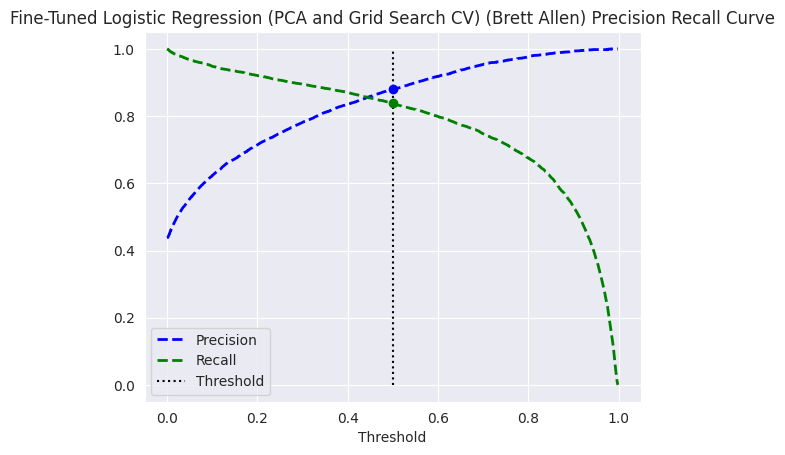

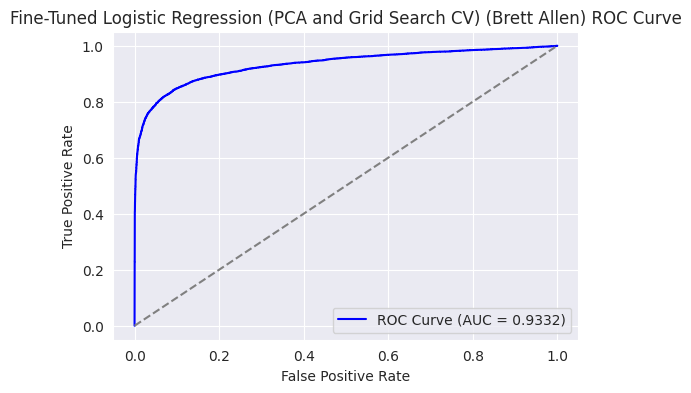

In [71]:
X_test_quantileTransformed_pca = logreg_pca_pipeline['pca'].transform(X_test_quantileTransformed)

# quick_evaluate(
#     model=logreg_pca_pipeline['logreg'],
#     test_data=X_test_quantileTransformed_pca,
#     test_labels=y_test,
#     display_labels=list(label_to_id.keys()),
#     model_name="Fine-Tuned Logistic Regression (Grid Search CV)"
# )
quick_evaluate(
    model=logreg_pca_pipeline['grid_search_logreg'].best_estimator_,
    test_data=X_test_quantileTransformed_pca,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (PCA and Grid Search CV) (Brett Allen)"
)

Using PCA and GridSearchCV does not improve the accuracy of the Logistic Regression model. We could iteratively try a different number of components through grid search but it is unlikely we will see better performance than the results of grid search on all available features.

##### Manual Hyperparameter Tuning

>>> Manual Hyperparameter Tuned Logistic Regression (Brett Allen) accuracy: 0.8821854336599256
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.88      0.88     20719
weighted avg       0.88      0.88      0.88     20719



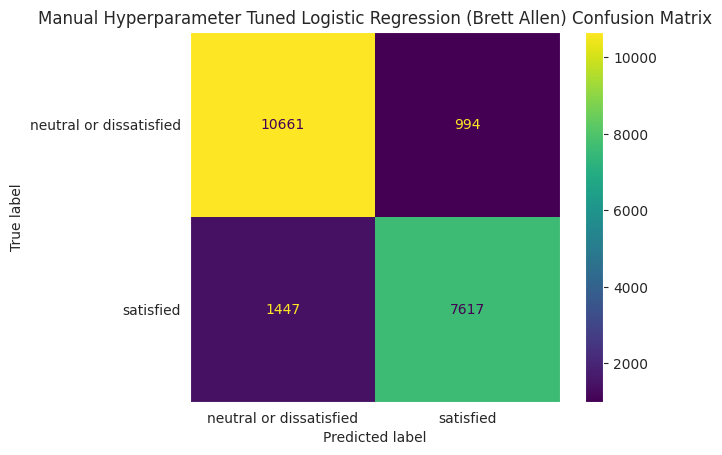

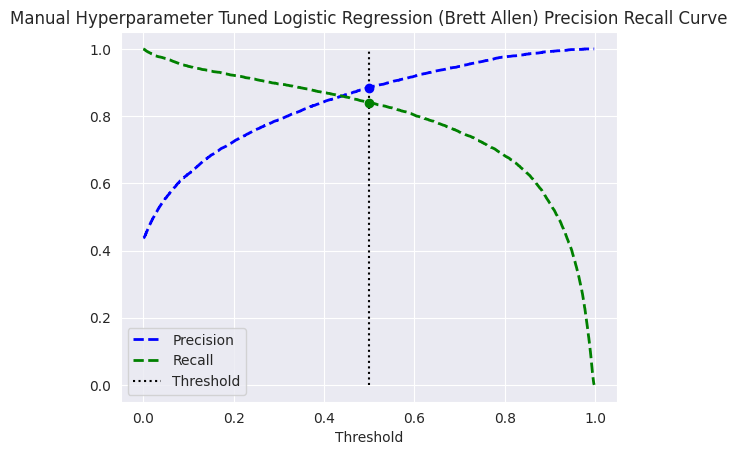

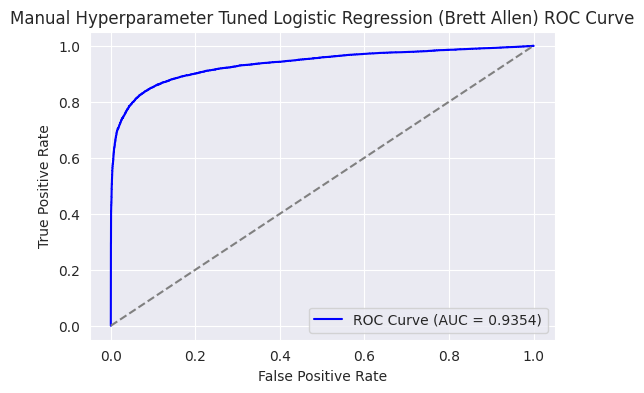

In [72]:
tuned_logreg_model = LogisticRegression(
    max_iter=1000, 
    C=0.1,
    solver='saga',
    penalty="elasticnet",
    l1_ratio=0.5, # equally divide use of l1 and l2 norm using 0.5
    random_state=42
)
tuned_logreg_model.fit(X_train_quantileTransformed, y_train)

quick_evaluate(
    model=tuned_logreg_model,
    test_data=X_test_quantileTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Manual Hyperparameter Tuned Logistic Regression (Brett Allen)"
)

##### UMAP Visualization
Since the performance of the logistic regression model is not being improved with various fine-tuning techniques, it is likely that the data is not adequately linearly separable. We can verify this by using UMAP visualization.

In [73]:
reducer = umap.UMAP()

In [74]:
embedding = reducer.fit_transform(X_train_quantileTransformed)
embedding.shape, X_train_quantileTransformed.shape

((82875, 2), (82875, 22))

We can see there is only two features in the resulting UMAP transformation. This is because UMAP reduces the data to 2D by default. See https://umap-learn.readthedocs.io/en/latest/basic_usage.html

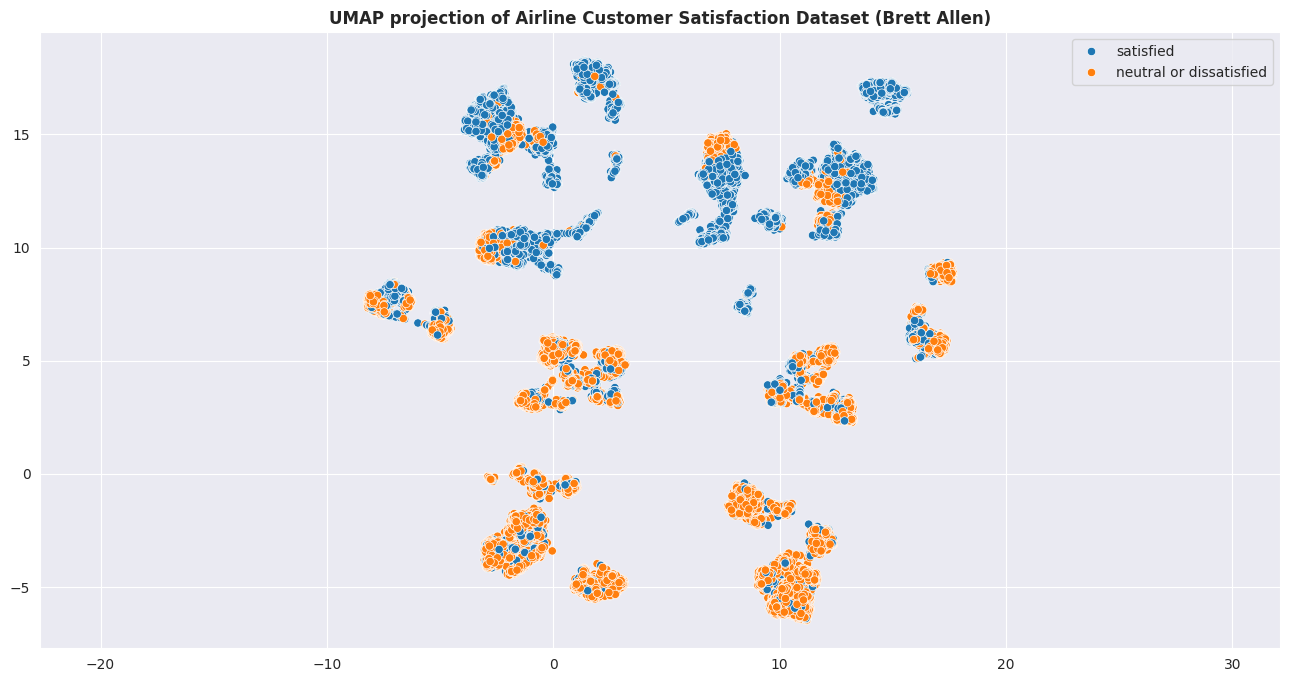

In [75]:
plt.figure(figsize=(16, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_train.map(id_to_label))
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of Airline Customer Satisfaction Dataset (Brett Allen)', weight='bold')
plt.legend()
plt.show()

We can see based on the UMAP visualization that it is rather challenging to separate the target label in a linear fashion. Many of the clusters are mixed between `neutral or dissatisfied` and `satisfied`. This observation is in alignment with the model performance observed from logistic regression. The model cannot be improved past `88.2%` accuracy because the dataset is not linearly separable enough.

#### Conclusion/Insights
After cleaning the data and preparing the data for training, it was evident that log transform and quantile transform held the most promise in terms of normally distributed features. We were able to use a random forest classifier to identify the most important (statistically significant) features, which helped to gain insight on which features have the most influence on the labels. For example, the top 5 most important features were:
1) `ONLINE_BOARDING`
2) `INFLIGHT_WIFI_SERVICE`
3) `CLASS`
4) `TYPE_OF_TRAVEL`
5) `INFLIGHT_ENTERTAINMENT`

After identifying important features, we moved on to training a logistic regression model using quantile transformed data. The base model yielded promising results with approximately `88.2%` accuracy. Various fine-tuning techniques were applied such as grid search, random search, PCA with grid search, and manual hyperparameter tuning with an even distribution of `l1` and `l2` norm via `elasticnet`. Unfortunately, through exhaustive efforts, none of the fine-tuning approaches improved the model accuracy. Through UMAP visualization, we were able to determine that the dataset is not adequately linearly separable for logistic regression. Also, accuracy is not the best metric to use to evaluate logistic regression because the goal of logistic regression is to minimize loss (e.g., RMSE). 

In conclusion, while logistic regression is a good start, ensemble classifiers such as `random forest`, `AdaBoost`, `GradientBoost`, and `XGBoost` perform the best on this dataset. We can see evidence of this with the random forest model used to identify feature importance - the model had an accuracy of `96%` with all features included.

### MODEL NAME(S) HERE (Eeshani Gundi)

### Gradient Boosting and XGBoost (Sruthi Kapudasi)

In [79]:
models = {
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss')
}

In [80]:
def plot_cm(cm, model_name, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.gca().grid(False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

#### Train, Evaluate, and Fine-Tune

Training model: Gradient Boosting
Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     11655
           1       0.95      0.92      0.94      9064

    accuracy                           0.95     20719
   macro avg       0.95      0.94      0.95     20719
weighted avg       0.95      0.95      0.95     20719



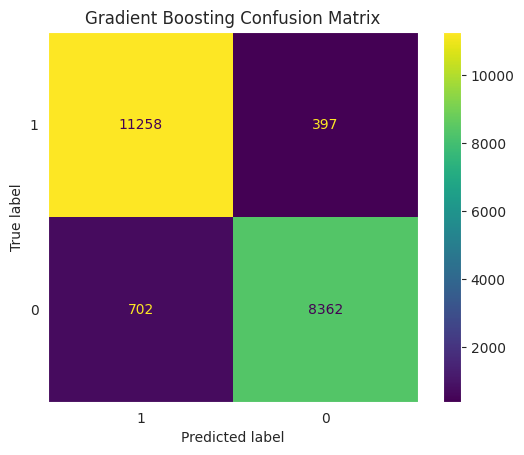

Training model: XGBoost
Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11655
           1       0.97      0.94      0.96      9064

    accuracy                           0.96     20719
   macro avg       0.96      0.96      0.96     20719
weighted avg       0.96      0.96      0.96     20719



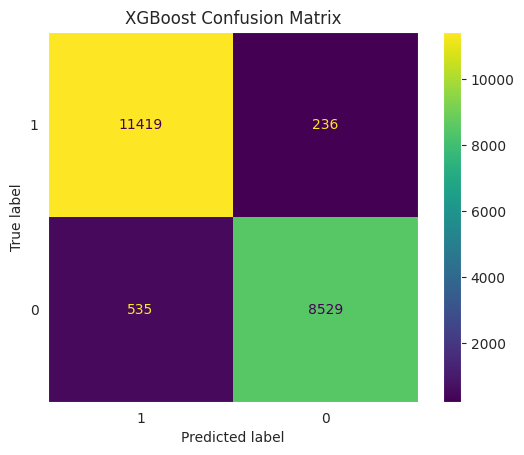

Tuning model: Gradient Boosting
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters for Gradient Boosting: {'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1}
Best Score for Gradient Boosting: 0.9602171945701358
Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11655
           1       0.97      0.94      0.96      9064

    accuracy                           0.96     20719
   macro avg       0.96      0.96      0.96     20719
weighted avg       0.96      0.96      0.96     20719



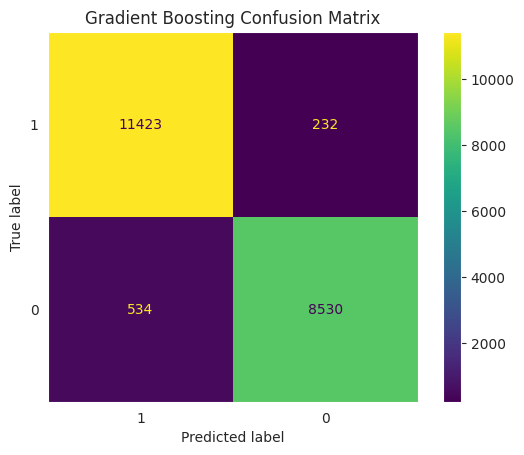

Tuning model: XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters for XGBoost: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__min_child_weight': 5, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.9}
Best Score for XGBoost: 0.9600723981900452
Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11655
           1       0.97      0.94      0.96      9064

    accuracy                           0.96     20719
   macro avg       0.96      0.96      0.96     20719
weighted avg       0.96      0.96      0.96     20719



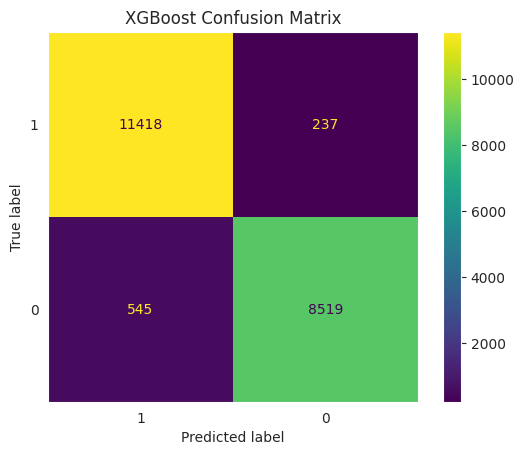

In [81]:
for model_name, model in models.items():
    print(f"Training model: {model_name}")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plot_cm(cm, model_name, labels=y_test.unique())

param_grids = {
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.001, 0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.8, 0.9, 1.0],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.001, 0.01, 0.1],
        'classifier__max_depth': [3, 5, 7],
        'classifier__min_child_weight': [1, 5, 10],
        'classifier__subsample': [0.8, 0.9, 1.0],
        'classifier__colsample_bytree': [0.8, 0.9, 1.0],
    }
}

for model_name, model in models.items():
    print(f"Tuning model: {model_name}")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    random_search = RandomizedSearchCV(pipeline, param_distributions=param_grids[model_name], 
                                       n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1)
    
    random_search.fit(X_train, y_train)
    
    print(f"Best Parameters for {model_name}: {random_search.best_params_}")
    print(f"Best Score for {model_name}: {random_search.best_score_}")

    y_pred = random_search.best_estimator_.predict(X_test)
    
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plot_cm(cm, model_name, labels=y_test.unique())

Plotting AUPRC for Gradient Boosting


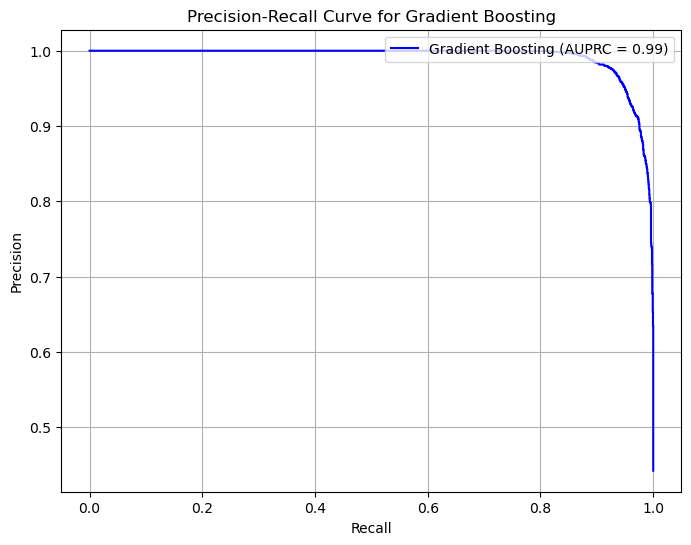

Plotting AUPRC for XGBoost


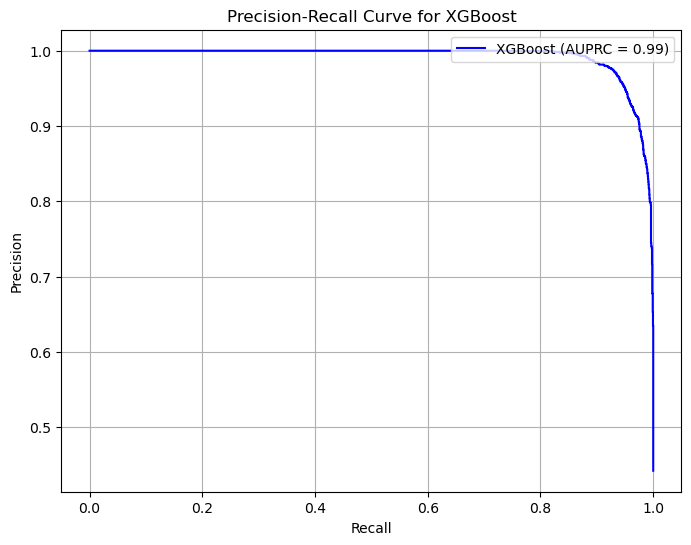

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Function to plot the Precision-Recall Curve
def plot_pr_curve(y_true, y_scores, model_name):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'{model_name} (AUPRC = {avg_precision:.2f})', color='b')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()

# Assuming 'random_search' holds the best estimator for each model
for model_name, model in models.items():
    print(f"Plotting AUPRC for {model_name}")
    
    best_estimator = random_search.best_estimator_
    
    # Get the predicted probabilities for the positive class
    y_scores = best_estimator.predict_proba(X_test)[:, 1]
    
    # Plot Precision-Recall Curve
    plot_pr_curve(y_test, y_scores, model_name)


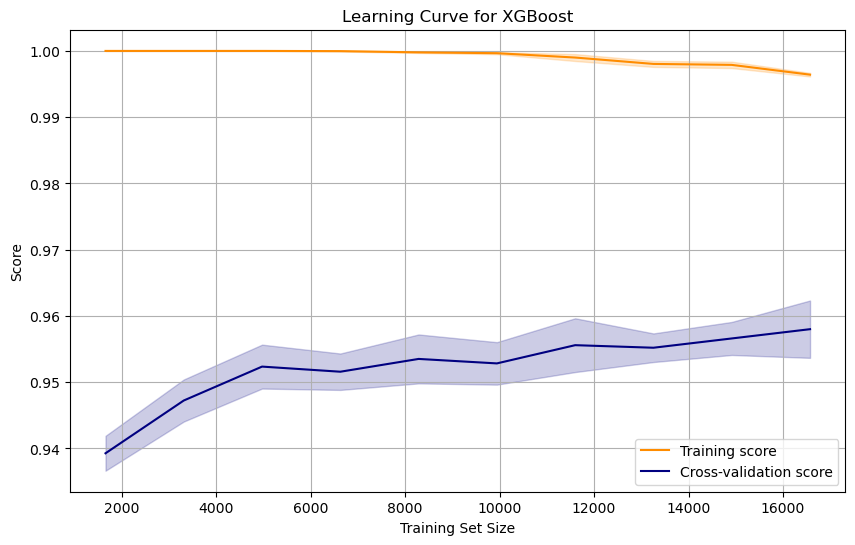

In [29]:
from sklearn.model_selection import learning_curve
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)

# Function to plot learning curve
def plot_learning_curve(estimator, X, y, title="Learning Curve for XGBoost", cv=5, scoring='accuracy'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )

    # Calculate the mean and standard deviation for both train and test scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.plot(train_sizes, train_scores_mean, label="Training score", color="darkorange")
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, color="darkorange", alpha=0.2)
    plt.plot(train_sizes, test_scores_mean, label="Cross-validation score", color="navy")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, color="navy", alpha=0.2)
    plt.xlabel("Training Set Size")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot the learning curve
plot_learning_curve(xgb_model, X_train, y_train, title="Learning Curve for XGBoost")

#### Observations 
- XGBoost seems to be the better model based on the small performance edge in terms of accuracy and the fact that it has fewer n_estimators (100 vs. 200 for Gradient Boosting), which may lead to faster predictions. The subsample and colsample_bytree parameters suggest the model is using a more conservative approach in terms of data sampling, which might be helping in reducing overfitting.
- Gradient Boosting is still a very solid model and provides similar results with slight differences in the precision/recall balance for Class 1(Satisfied).

#### Analyzing Feature Importance
Analyzing feature importance can provide insights into the key drivers of predictions and help identify potential areas for improvement.

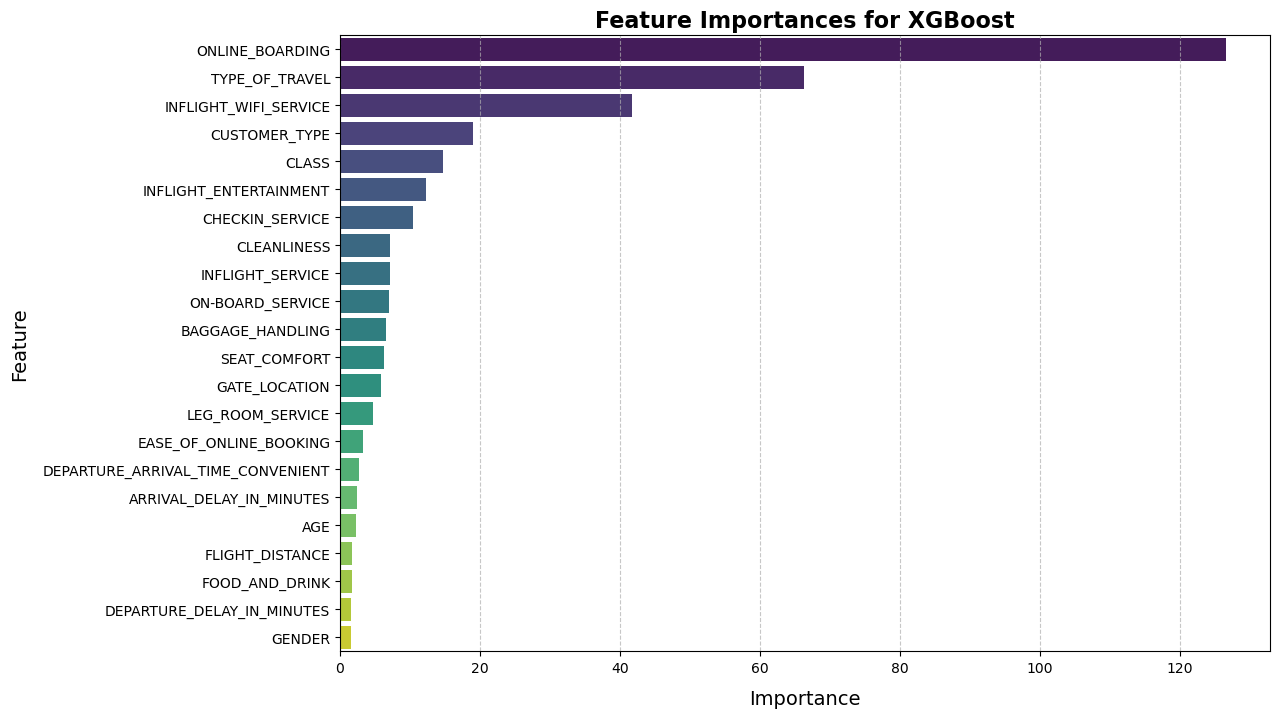

In [35]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Train the XGBoost model
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Extract feature importances and create a DataFrame
feature_importances = xgb_model.get_booster().get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(
    list(feature_importances.items()), columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=False)

# Plot feature importances using Seaborn for all features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.xlabel('Importance', fontsize=14, labelpad=10)
plt.ylabel('Feature', fontsize=14, labelpad=10)
plt.title('Feature Importances for XGBoost', fontsize=16, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


#### Conclusion/Insights

**Model Performance:**

Based on the provided precision-recall curves, AUPRC scores, and learning curve, both XGBoost and Gradient Boosting demonstrate exceptional performance. The AUPRC values for both models are very close to 1, indicating high accuracy in classifying instances, particularly in the positive class (Satisfied).

**Model Comparison:**

* **XGBoost:**
    - Slightly higher AUPRC score, suggesting a potential edge in overall performance.
    - Fewer `n_estimators` (100 vs. 200 for Gradient Boosting), potentially leading to faster predictions.
    - Conservative approach with `subsample` and `colsample_bytree` parameters, potentially mitigating overfitting.
    - The learning curve shows a slight gap between the training and cross-validation scores, indicating some overfitting, but it's not significant.

* **Gradient Boosting:**
    - Strong performance comparable to XGBoost.
    - More `n_estimators`, potentially leading to higher accuracy but potentially slower predictions.

**Further Analysis:**

- **Error Analysis:** Examining misclassified instances can help identify patterns and areas where the models might be struggling.
- **Model Ensembling:** Combining the predictions of multiple models can often improve overall performance. Techniques like bagging and boosting can be explored.



### Random Forest Classifier (Bharath Prabhakaran)

In [ ]:
# Define the parameter grid for Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],         # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],        # Maximum depth of each tree
    'min_samples_split': [2, 5, 10]         # Minimum number of samples required to split an internal node
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_rf_model.predict(X_test)

# Evaluate and print classification metrics
print("Best Parameters:", best_params)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Manual Hyperparameter Tuning
(n_estimators, max_depth, and min_samples_split).

n_estimators: Controls the number of trees in the forest. A higher number generally improves model performance but increases computation time.

max_depth: Limits how deep each tree can grow, helping to prevent overfitting on complex data by controlling model complexity.

min_samples_split: Defines the minimum samples needed to split an internal node.

In [ ]:
# Manual tuning: Trying a few values for key parameters
# Setting up and training models with manual hyperparameter choices
manual_params = [
    {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5},
    {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10},
    {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 2}
]

# Store results for plotting
manual_scores = []
models = []

# Train and evaluate manually tuned models
for params in manual_params:
    rf_model = RandomForestClassifier(random_state=42, **params)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    manual_scores.append((params, f1))
    models.append(rf_model)

# Select the best manually tuned model for plotting
best_manual_model = max(models, key=lambda m: classification_report(y_test, m.predict(X_test), output_dict=True)['weighted avg']['f1-score'])
y_pred_best_manual = best_manual_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best_manual)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Best Manual Model")
plt.show()

# Precision-Recall Curve
y_probs = best_manual_model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision, marker='.', label="Random Forest (Manual Tuning)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Parameter vs F1-score Plot
param_names = ['Model 1', 'Model 2', 'Model 3']
f1_scores = [score[1] for score in manual_scores]
plt.plot(param_names, f1_scores, marker='o')
plt.title("F1-Score by Manually Tuned Parameters")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.show()

manual_scores

Confusion Matrix: Shows the classification performance of the best manually tuned model, illustrating true positives, false positives, and other rates.

Precision-Recall Curve: Highlights the trade-off between precision and recall, helpful for assessing model balance. Curve demonstrated that the Random Forest model could maintain a good balance between precision and recall, minimizing trade-offs that could result in misclassification.

Parameter vs. F1-Score Plot: Compares F1-scores across the three manually tuned models, showing Model 3 as the best performer.


Among the manually tuned models, we observed that increasing n_estimators and adjusting min_samples_split led to optimal F1-scores, confirming the robustness of the chosen parameters.



**Insights**

Data Patterns: Features like age, flight distance, and customer type showed a significant influence on prediction outcomes. For instance, customer types like loyal or first-time customers correlated with higher satisfaction rates.

**Future Work**

Additional fine-tuning of parameters, such as max_features or experimenting with deeper trees, could further enhance performance without overfitting. XGBoost or neural networks, could potentially improve prediction accuracy



### Support Vector Classifier (Nandhu Unnikrishnan)

#### Apply Transformations

In [ ]:
# Impute missing values with the median
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale the imputed data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#### Train and Evaluate

In [4]:
# Initialize and train the SVM model
svc_model = SVC(random_state=42, probability=True)
svc_model.fit(X_train_scaled, y_train)

# Predictions and evaluation
y_pred = svc_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9559978441638436
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     14573
           1       0.96      0.94      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.95      0.96     25976
weighted avg       0.96      0.96      0.96     25976



In [5]:
from sklearn.preprocessing import MinMaxScaler

# Scale the data using MinMaxScaler
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

# Initialize and train the SVM model with MinMax-scaled data
svc_model_minmax = SVC(random_state=42, probability=True)
svc_model_minmax.fit(X_train_minmax, y_train)

# Predictions and evaluation with MinMax-scaled data
y_pred_minmax = svc_model_minmax.predict(X_test_minmax)
print("SVM with MinMaxScaler - Accuracy:", accuracy_score(y_test, y_pred_minmax))
print("Classification Report for SVM with MinMaxScaler:\n", classification_report(y_test, y_pred_minmax))

SVM with MinMaxScaler - Accuracy: 0.9517246689251617
Classification Report for SVM with MinMaxScaler:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     14573
           1       0.96      0.93      0.94     11403

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



#### Fine-Tuning

In [6]:
# Hyperparameter tuning with Grid Search
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best model and performance
print("Best Parameters from Grid Search:", grid_search.best_params_)
print("Best Grid Search Accuracy:", grid_search.best_score_)

# Evaluate the best model
y_pred_grid = grid_search.best_estimator_.predict(X_test_scaled)
print("Grid Search Test Accuracy:", accuracy_score(y_test, y_pred_grid))
print("Classification Report for Grid Search:\n", classification_report(y_test, y_pred_grid))

Best Parameters from Grid Search: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Grid Search Accuracy: 0.9571912477058637
Grid Search Test Accuracy: 0.9604250076994149
Classification Report for Grid Search:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97     14573
           1       0.97      0.94      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



In [7]:
# Manual Hyperparameter Tuning
tuned_params = [
    {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'},
    {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'},
    {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
]

best_accuracy = 0
best_params = {}

for params in tuned_params:
    # Initialize SVM with specific parameters
    svc_model = SVC(C=params['C'], gamma=params['gamma'], kernel=params['kernel'], random_state=42, probability=True)
    svc_model.fit(X_train_scaled, y_train)
    
    # Evaluate on test data
    y_pred = svc_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Parameters: {params} -> Accuracy: {accuracy:.4f}")
    
    # Track best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_params = params

print(f"Best Manual Tuning Parameters: {best_params} with Accuracy: {best_accuracy:.4f}")

Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'} -> Accuracy: 0.8743
Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'} -> Accuracy: 0.9560
Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'} -> Accuracy: 0.9604
Best Manual Tuning Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'} with Accuracy: 0.9604


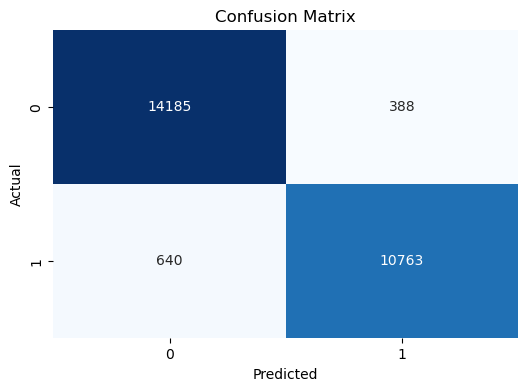

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

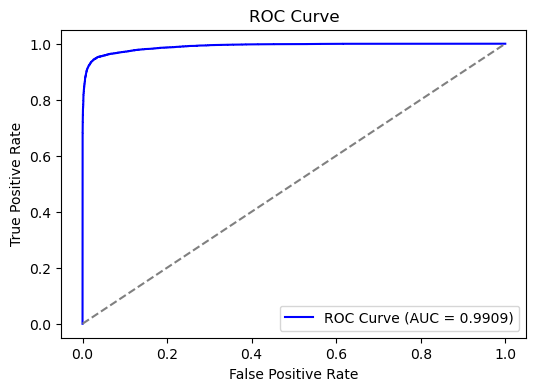

In [9]:
# ROC Curve
y_pred_prob = svc_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.show()

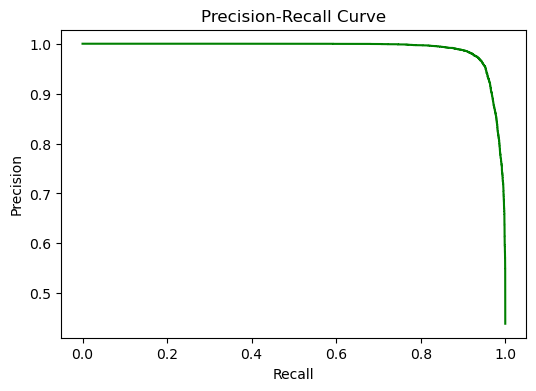

In [10]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='green')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

#### Conclusions/Insights
Insights:
- Inflight service features like wifi and entertainment correlate positively with satisfaction.
- SVM model effectively predicts satisfied vs. dissatisfied passengers.
- Age distributions show slight differences in satisfaction across age groups, suggesting varied expectations.

Future Work:
- Encountered categorical data error; solved by one-hot encoding.
- Missing values led to errors, handled by imputing with the median.
- Future steps: Try other models like random forests, tune more hyperparameters, and test on specific traveler segments.